# Analyze global fit results

In [38]:
import numpy as np
import sys
import os
import subprocess
import matplotlib as mpl
from matplotlib import pyplot as plt

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser
%aimport fit_utils.EFT_matching

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser
import fit_utils.EFT_matching as EFT_matching

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
model = "Z2SSM"
working_dir = "."

all_scenarios = [
    # f"{model}_FCCee240"
    f"{model}_FCCee240_FCCee365"
    # f"{model}_FCCee240_FCCee365_HLLHClambda"
]

loop_order = "1"
# loop_order = "2"
loop_order_str = "_one_loop_inputs" if loop_order == "1" else ""

specs = [
    # "fits_long",
    # "fits_full",
    # "fits_realistic_HL_LHC_WFR_kala2_input_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_HLLHC_Higgs_small_priors_long",
    # # "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long",
    # # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long",
    f"fits_realistic_HL_LHC{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_realistic_HL_LHC_long",
    # "fits_realistic_HL_LHC_all_EW_mods_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_sqrt_s_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_sqrt_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_small_priors_long",
    # # "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_external_leg_small_priors_long",
    # "fits_realistic_HL_LHC_small_priors_long",
    # "fits_realistic_HL_LHC_no_quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long",
    # # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.0148_theoerr365_0.0147_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long"
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",

    ##### ELLIPTIC ESTIMATES #####
    # # Estimates EXCLUDING the O(1/Lambda_NP^2) curve
    f"fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict",
    # # Estimates INCLUDING the O(1/Lambda_NP^2) curve
    f"fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict",

    ##### RECTANGULAR ESTIMATES, with 2D scaling #####
    # # # Estimates EXCLUDING the O(1/Lambda_NP^2) curve
    f"fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_1_theoerr365_1_klam_dependent_a240_2.06e-05_b240_7.03e-05_c240_-8.83e-05_a365_5.8e-05_b365_-0.000296_c365_0.00031{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict",
    # # # Estimates INCLUDING the O(1/Lambda_NP^2) curve
    f"fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000397_b240_-0.000673_c240_0.000277_a365_0.000403_b365_-0.000848_c365_0.000466{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict",

]

spec_labels_dict = {
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long" : "Original",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long" : "Using HEPfit C1 values",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : "Using HEPfit C1 values \n(including decay rates)",
    # # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : "Original fits",
    # "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long" : "Using HEPfit formulas",
    f"fits_realistic_HL_LHC{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : f"{loop_order}-loop Z2SSM inputs",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : r"Uncertainty estimates"+"\nw/o $\mathcal{O}(1/\Lambda^2)$ curve",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.0148_theoerr365_0.0147_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long" : r"Estimates with $\mathcal{O}(1/\Lambda^2)$ curve",

    # # Estimates EXCLUDING the O(1/Lambda_NP^2) curve
    f"fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict" : r"Unc. estimates w/o $\mathcal{O}(1/\Lambda^2)$ curve",
    # # Estimates INCLUDING the O(1/Lambda_NP^2) curve
    f"fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict" : r"Unc. estimates with $\mathcal{O}(1/\Lambda^2)$ curve",

    ##### RECTANGULAR ESTIMATES, with 2D scaling #####
    # # # Estimates EXCLUDING the O(1/Lambda_NP^2) curve
    f"fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_1_theoerr365_1_klam_dependent_a240_2.06e-05_b240_7.03e-05_c240_-8.83e-05_a365_5.8e-05_b365_-0.000296_c365_0.00031{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict" : r"Unc. estimates w/o $\mathcal{O}(1/\Lambda^2)$ curve",
    # # # Estimates INCLUDING the O(1/Lambda_NP^2) curve
    f"fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000397_b240_-0.000673_c240_0.000277_a365_0.000403_b365_-0.000848_c365_0.000466{loop_order_str}_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict" : r"Unc. estimates with $\mathcal{O}(1/\Lambda^2)$ curve",

}
spec_labels = list(spec_labels_dict.values())

model_specs = {
    # f"{model}_FCCee240" : specs
    f"{model}_FCCee240_FCCee365" : specs,
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : specs,
}
scenario_titles_dict = {
    # f"{model}_FCCee240" : rf"FCC-ee$_{{240}}$",
    f"{model}_FCCee240_FCCee365" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$",
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$ + $\kappa_{{\lambda}}$ at HL-LHC",
}
scenario_titles = list(scenario_titles_dict.values())

model_specs_labels = {
    # f"{model}_FCCee240" : specs
    f"{model}_FCCee240_FCCee365" : spec_labels,
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : specs,
}


results_dirs = specs
# results_dirs = [ model_specs["Z2SSM_FCCee240_FCCee365"] for spec in specs ]
# results_dir = "comparison_NPs_scaled"
# results_dir_compare = "comparison_original_HEPfitC1_C1decayrates_SMEFTformula"
# results_dir_compare = "comparison_original_with_NPs_with_without_blue_curve"
results_dir_compare = f"comparison_original{loop_order_str}_with_klam_dependent_NPs_with_without_blue_curve"
# results_dir_compare = specs[0]

# num_BPs = 8
# BPs = [f"BP_{i}" for i in range(num_BPs)]
BPs = []

# num_BPOs = 2
# BPOs = [f"BPO_{i}" for i in range(num_BPOs)]
BPOs = []

# num_BPBs = 17
# BPBs = [f"BPO_{i}" for i in range(num_BPBs)]
BPBs = []

# num_BPBnews = 14
# BPBnews = [f"BPBnew_{i}" for i in range(num_BPBnews)]
BPBnews = ["BPBnew_0", "BPBnew_1", "BPBnew_2", "BPBnew_4", ]
# BPBnews = []

BPs = BPs + BPOs + BPBs + BPBnews

BP_names = [f"BP {i}" for i in range(len(BPs))]

BP_lambdas_all = [
    1.0643594459030925, # BPB_0
    2.068362744578383,  # BPB_1
    3.41660475844658,   # BPB_2
    0.9197317035823376, # BPB_3
    4.996504503173265,  # BPB_4
    2.723103795696014,  # BPB_5
    6.114019817191308,  # BPB_6
    4.878015572616551,  # BPB_7
    7.24831645311373,   # BPB_8
    7.005268951781772,  # BPB_9
    8.535635929341407,  # BPB_10
    8.84021000223677,   # BPB_11
    9.584476423981522,  # BPB_12
    10.34814810189343,  # BPB_13
]

BP_lambdas_0124 = [
    1.0643594459030925, # BPB_0
    2.068362744578383,  # BPB_1
    3.41660475844658,   # BPB_2
    4.996504503173265,  # BPB_4
]

BP_lambdas_0124_1L = [
    1.0163047292403735,	 # BPBnew_0
    1.7062047495440402,	 # BPBnew_1
    2.5080254466112333,	 # BPBnew_2
    # 0.9039188316498036,	 # BPBnew_3
    3.3346734140060854,	 # BPBnew_4
    # 1.824117680395864,	 # BPBnew_5
    # 3.8686891648430426,	 # BPBnew_6
    # 2.9200538244698144,	 # BPBnew_7
    # 4.413812747631958,	 # BPBnew_8
    # 4.028931096630989,	 # BPBnew_9
    # 4.987738770945345,	 # BPBnew_10
    # 4.976927802452023,	 # BPBnew_11
    # 5.451304727293613,	 # BPBnew_12
    # 5.7864902366438695,	 # BPBnew_13
]

if loop_order == "1": BP_lambdas_0124 = BP_lambdas_0124_1L


plot_titles_specs = { 
    scenario : { 
        # spec : f"{scenario_titles_dict[scenario]} scenario \n{spec_labels_dict[spec]}" 
        spec : f"{spec_labels_dict[spec]}" 
        for spec in model_specs[scenario] 
    } 
    for scenario in all_scenarios
}

plot_titles_bps = { 
    BP : {
        scenario : rf"{model} ({BP_name}), {scenario_title}"
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

colors_bps = ["tab:blue", "tab:orange", "tab:green", "tab:red",]

colors_specs = ["tab:blue", "tab:green", "tab:red",]

## Copy kappa_lambda distributions to the `comparison_plots` directory

In [40]:
utils.group_plots(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
)

cp: cannot stat './BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory
cp: cannot stat './BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory
cp: cannot stat './BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory
cp: cannot stat './BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory
cp: cannot stat './BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realist

Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_0_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_1_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_2_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/deltalHHH_HLLHC_mod_BPBnew_4_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_depen

cp: cannot stat './BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory
cp: cannot stat './BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory


Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/deltalHHH_HLLHC_mod_BPBnew_1_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/deltalHHH_HLLHC_mod_BPBnew_2_Z2SSM_FCCee240_FCCee365.pdf


cp: cannot stat './BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory
cp: cannot stat './BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory


Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/deltalHHH_HLLHC_mod_BPBnew_4_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/deltalHHH_HLLHC_mod_BPBnew_0_Z2SSM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_sma

cp: cannot stat './BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory
cp: cannot stat './BPBnew_2/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/deltalHHH_HLLHC_mod.pdf': No such file or directory
cp: cannot stat './BPBnew_4/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845_one_loop_inputs_use_HEPfit_C1_values_de

## Print $\kappa_\lambda$ results to a text file
For each model specification and collider scenario

In [41]:
utils.print_klam_results(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
)


Reading klam fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_deca

## Compare $\kappa_\lambda$ results between benchmark points
For each model specification and collider scenario


Reading klam fit results


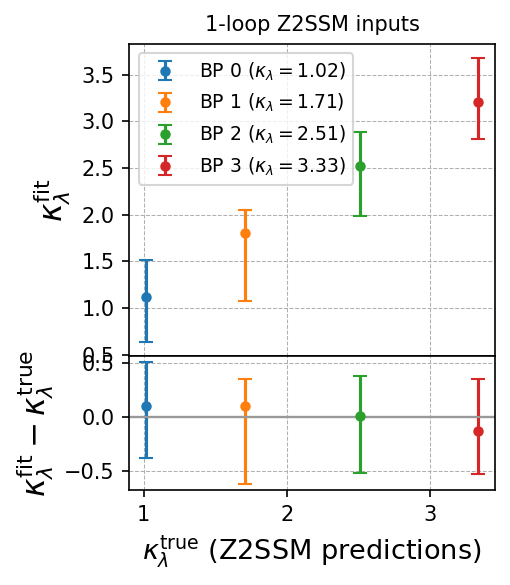

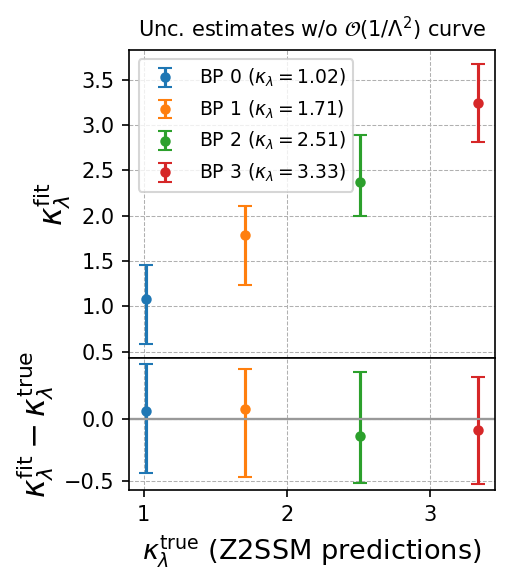

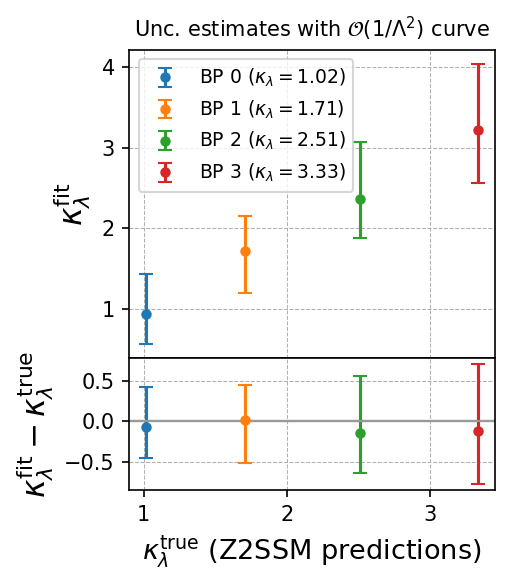

In [42]:
utils.generate_klam_comparison_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=None,
    plot_titles=plot_titles_specs,
    colors=colors_bps,
    show_plots=True,
    asym_errors=True,
)


Reading klam fit results


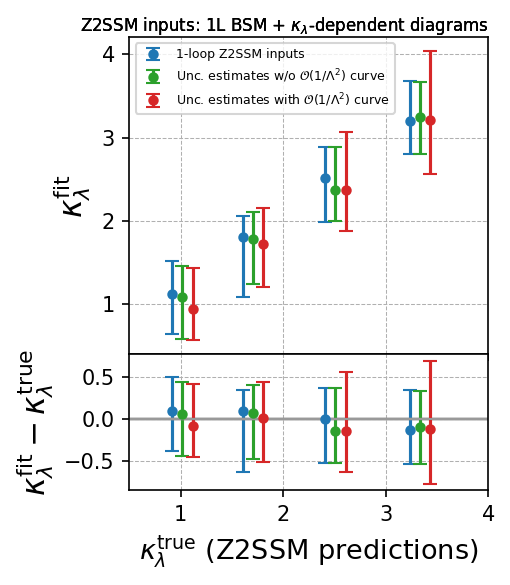


Reading klam fit results


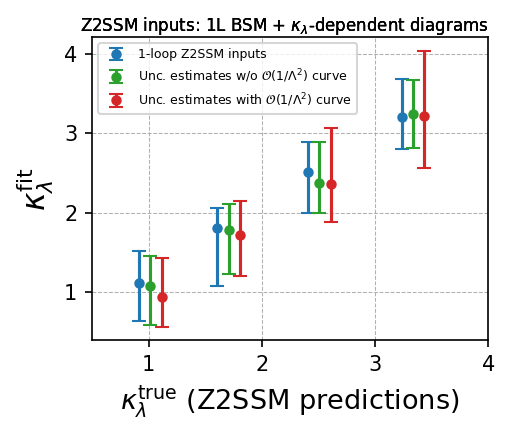

In [43]:
colors = ["tab:blue", "tab:green", "tab:red",]

if loop_order == "2":
    x_lim = (0.5, 5.5) 
elif loop_order == "1":
    x_lim = (0.5, 4.0)

upper_right_text = rf"Z2SSM inputs: {loop_order}L BSM + $\kappa_\lambda$-dependent diagrams"

utils.generate_klam_comparison_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors_specs,
    # # plot_true_klam={"color": "tab:red", "s": 50},
    plot_true_klam=None,
    show_plots=True,
    x_lim = x_lim,
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=6,
    spec_distance=0.2,
    upper_right_text=upper_right_text,
    asym_errors=True,
)

utils.generate_klam_comparison_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors_specs,
    # # plot_true_klam={"color": "tab:red", "s": 50},
    plot_true_klam=None,
    show_plots=True,
    x_lim = x_lim,
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=6,
    spec_distance=0.2,
    upper_right_text=upper_right_text,
    no_bottom_axis=True,
    figsize=(3.5,3),
    asym_errors=True,
)

## Compare the posterior $\kappa_\lambda$ distribution between different model specifications

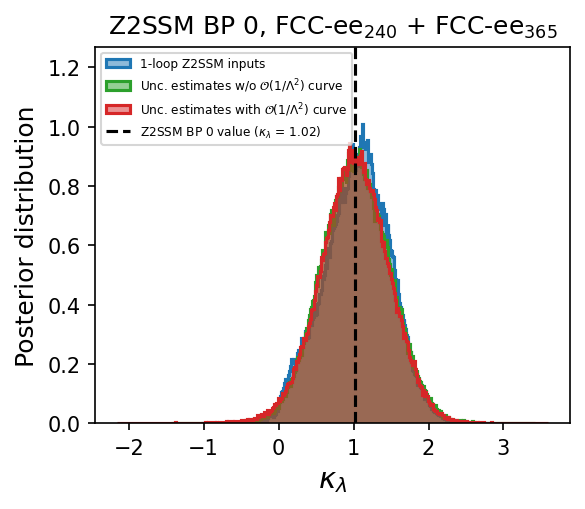

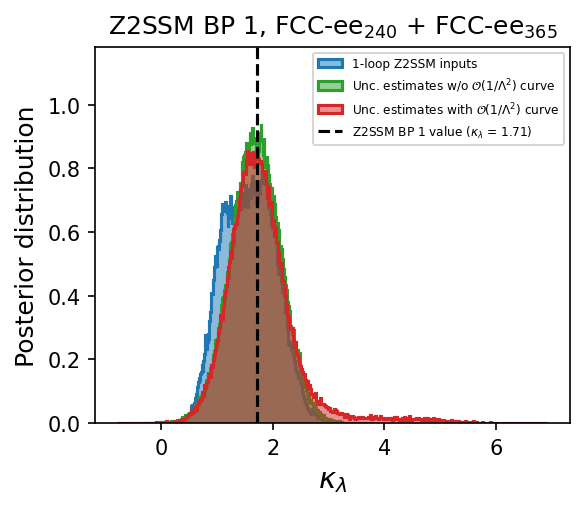

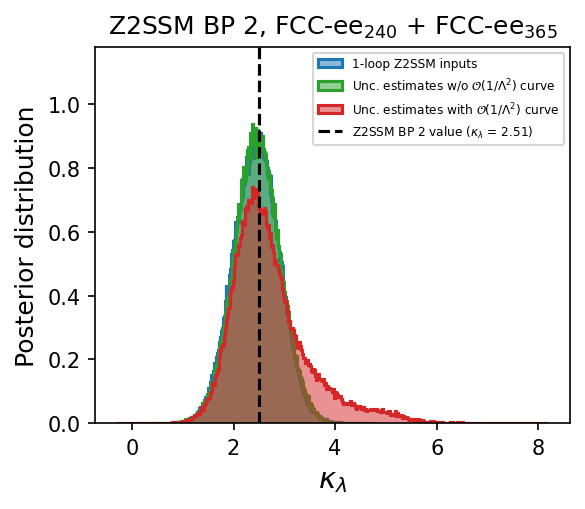

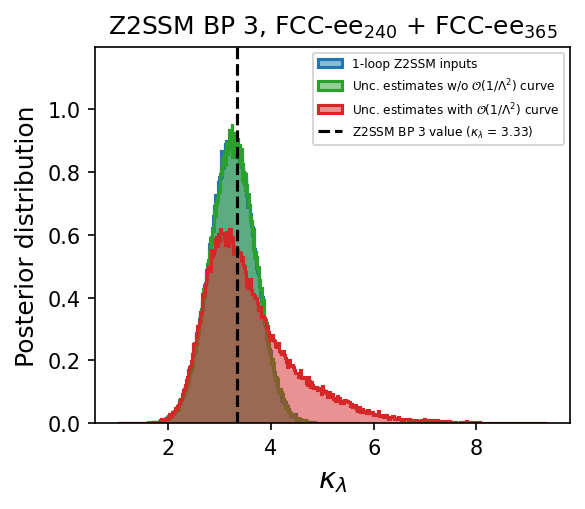

In [44]:
utils.compare_BP_results_uproot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    spec_labels=spec_labels,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
    model=model,
    scenario_titles=None,
    plot_titles=None,
    colors=colors_specs,
    show_plots=True,
    legend_fontsize=5.8,
)

## Generate summary $\LaTeX$ table for $\kappa_\lambda$ results

In [45]:
utils.generate_klam_latex_table(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    spec_labels=spec_labels,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas_0124,
)


Reading klam fit results
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/Statistics.txt
Reading file: ./BPBnew_0/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_0.000754_b240_-0.00149_c240_0.000743_a365_0.000788_b365_-0.00162_c365_0.000845_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict/Observables/Statistics.txt
Reading file: ./BPBnew_1/Z2SSM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_deca

## Generate pull plots for parameters


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict
Full fit flag: use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict
Files considered:
- Globalfits/AllOps/d6Ops

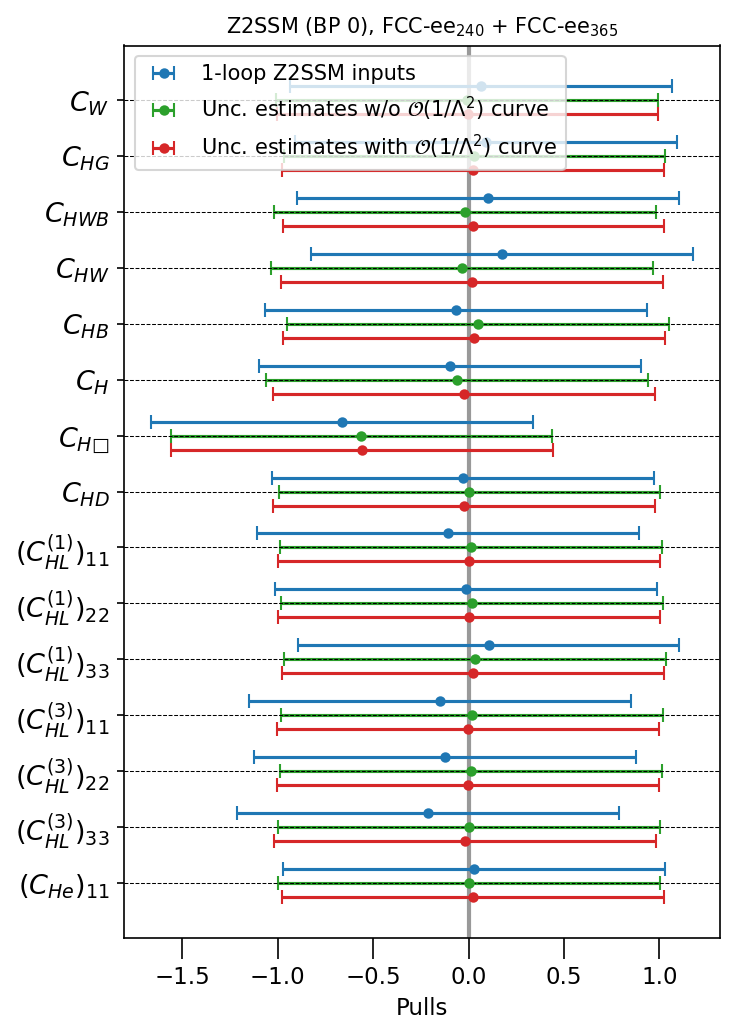

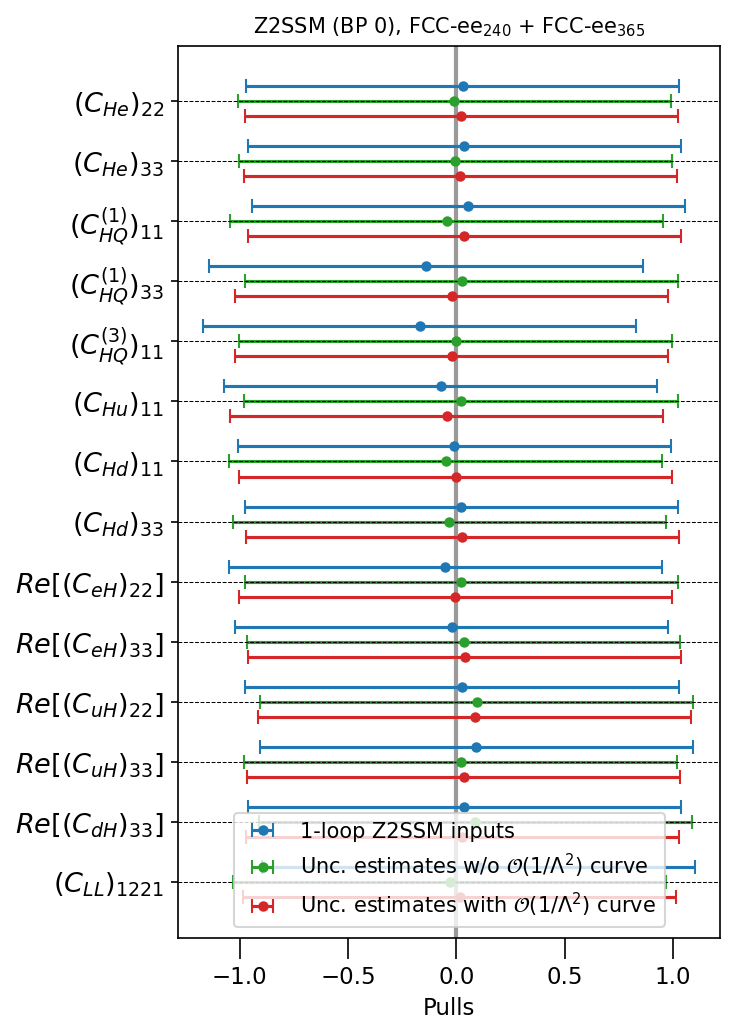

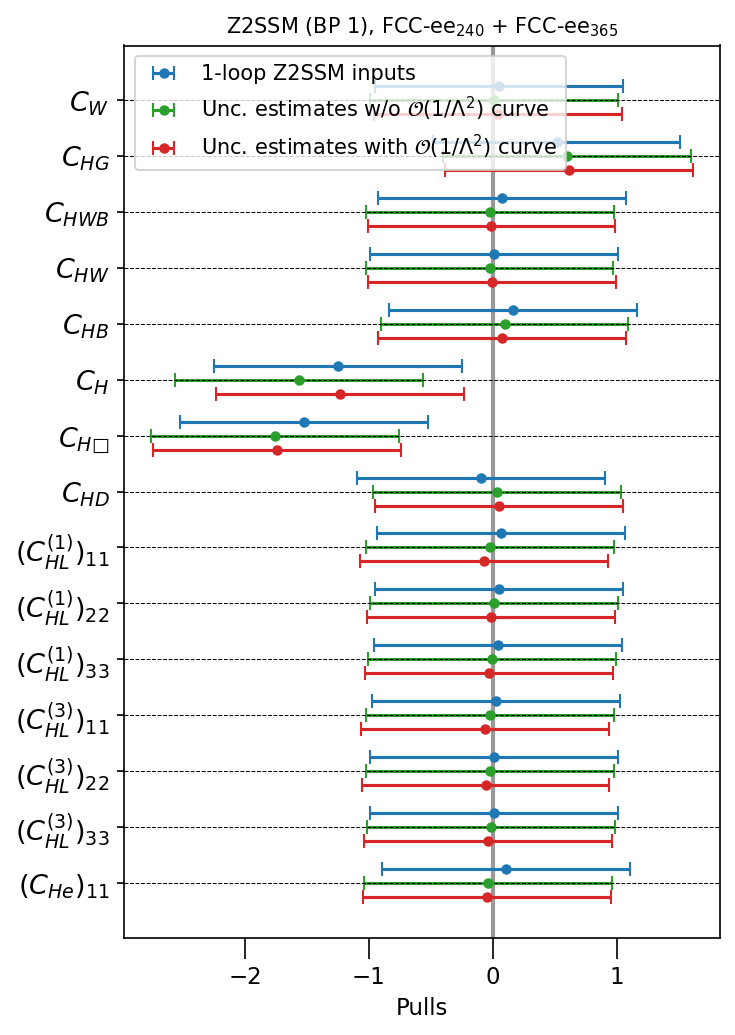

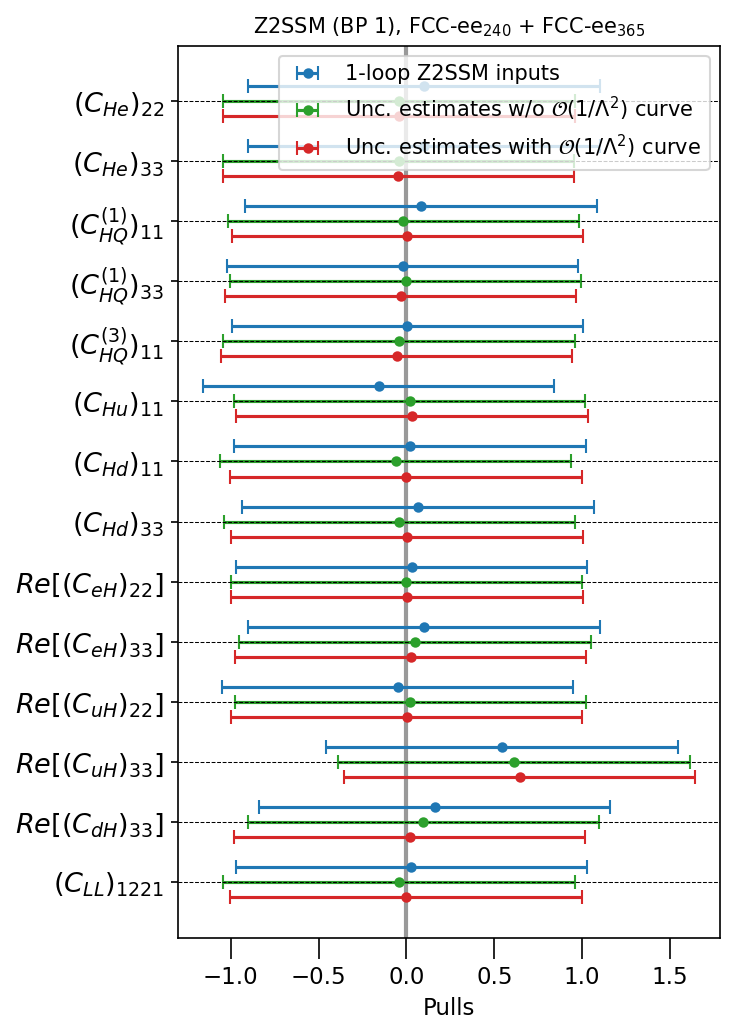

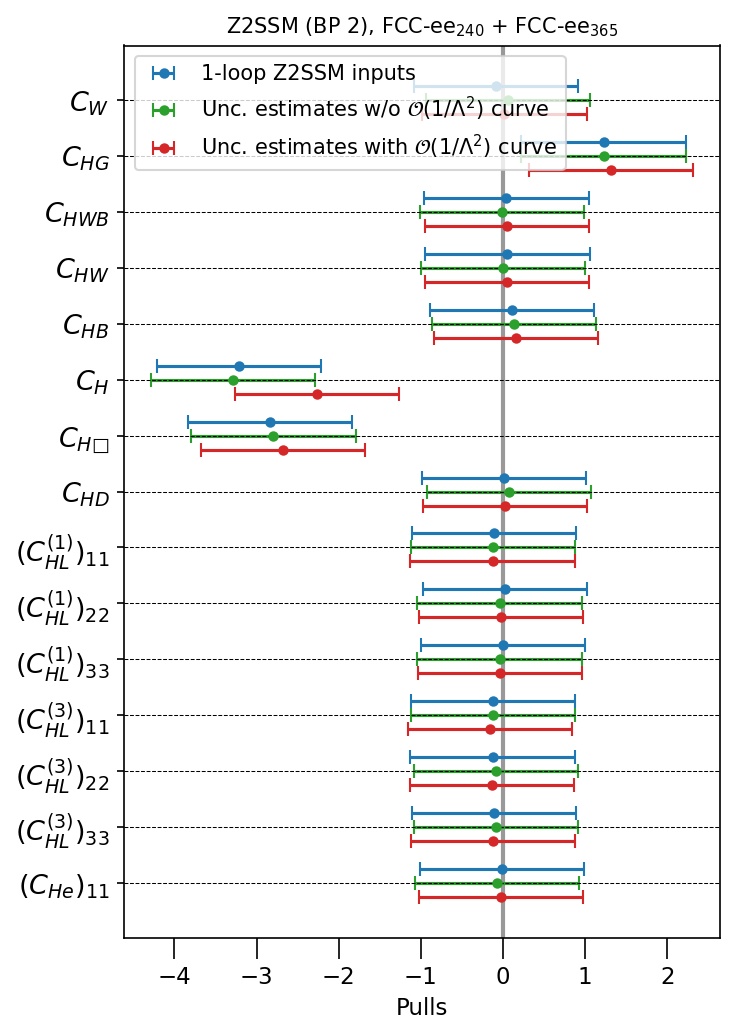

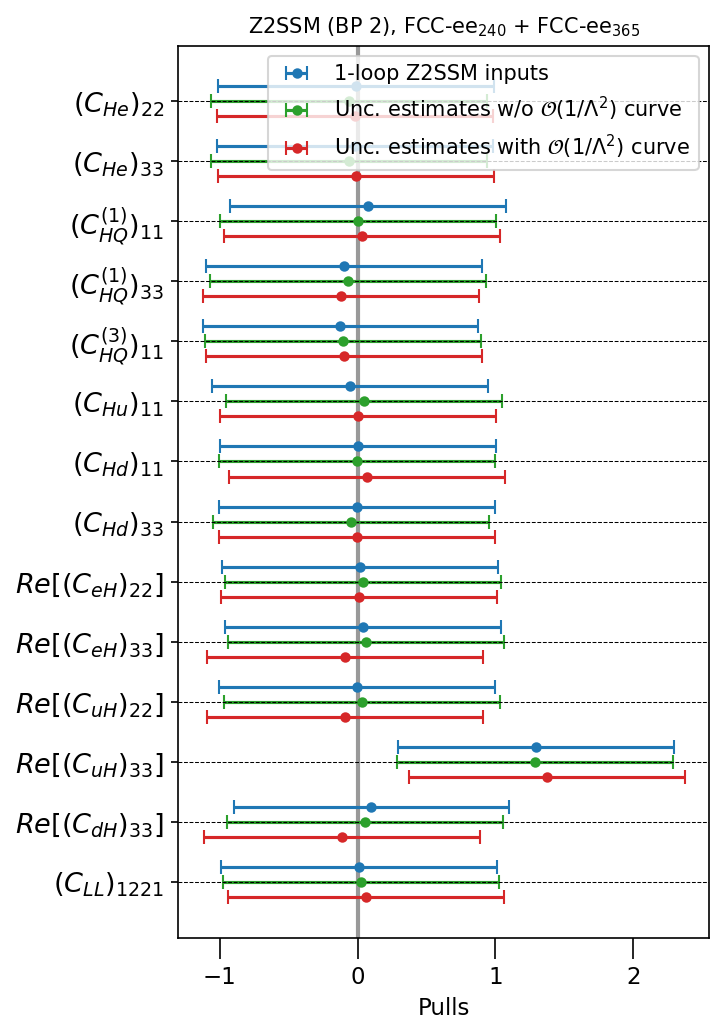

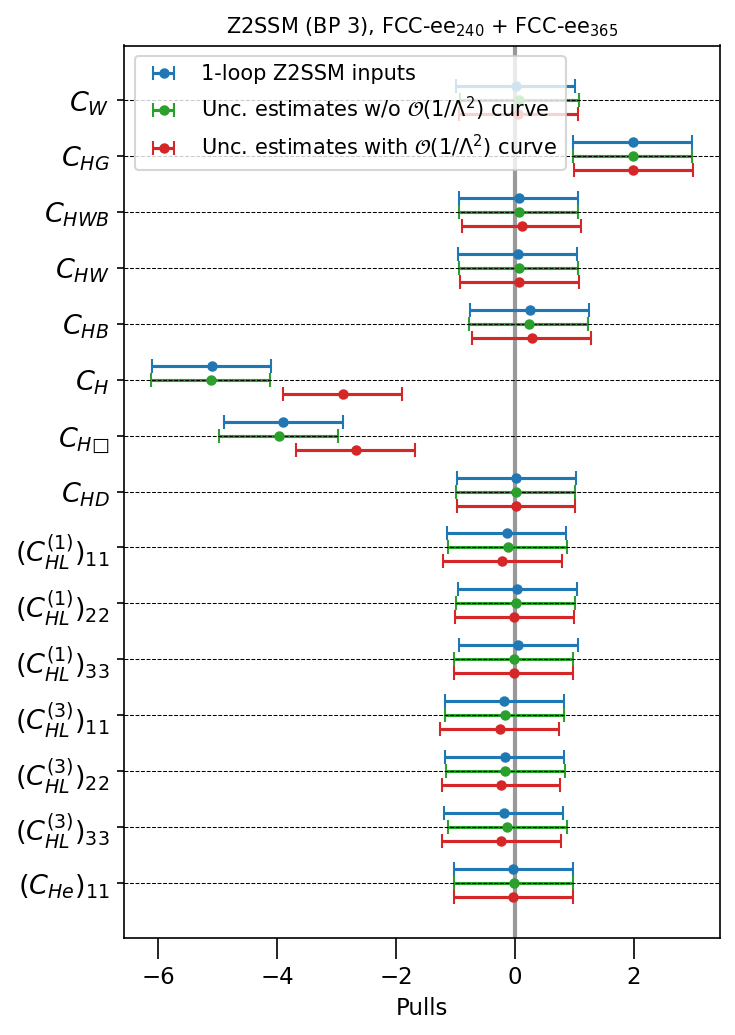

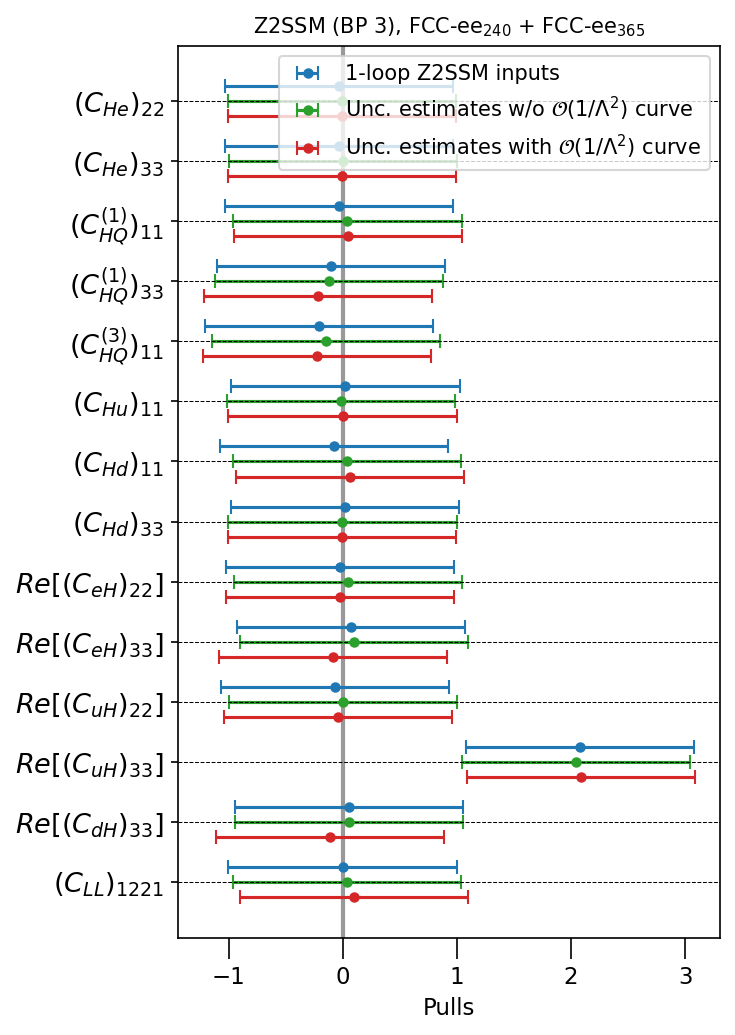

In [46]:
pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles_bps,
    model=model,
    colors=colors_specs,
    show_plots=True,
    nvar_per_plot=15,
    figsize=(5, 7),
)


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict
Full fit flag: use_new_NPs_theoerr240_1_theoerr365_1_klam_dependent_a240_1.18e-05_b240_2.3e-05_c240_0.000161_a365_2.12e-05_b365_-6.32e-05_c365_0.000304_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_strict
Files considered:
- Globalfits/AllOps/d6Ops

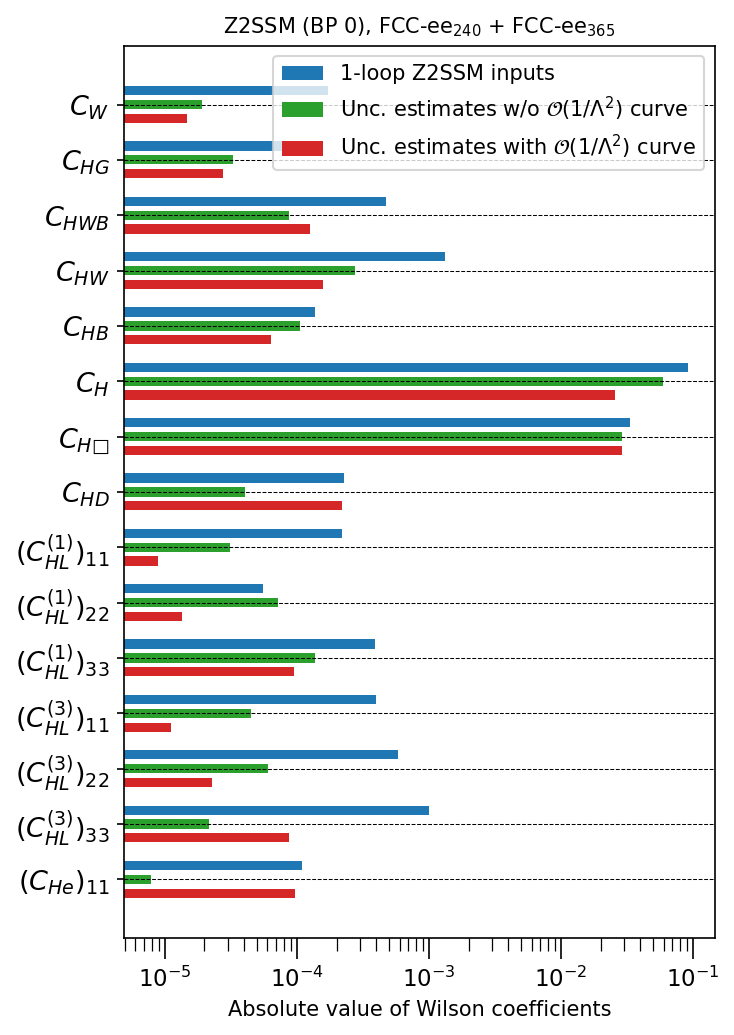

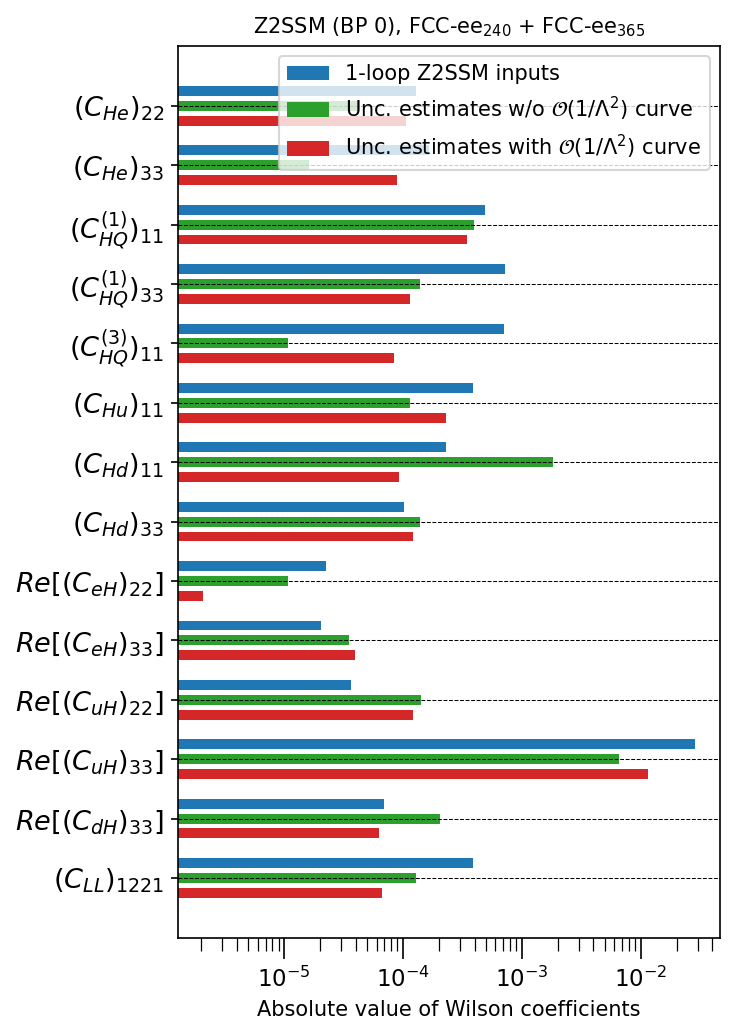

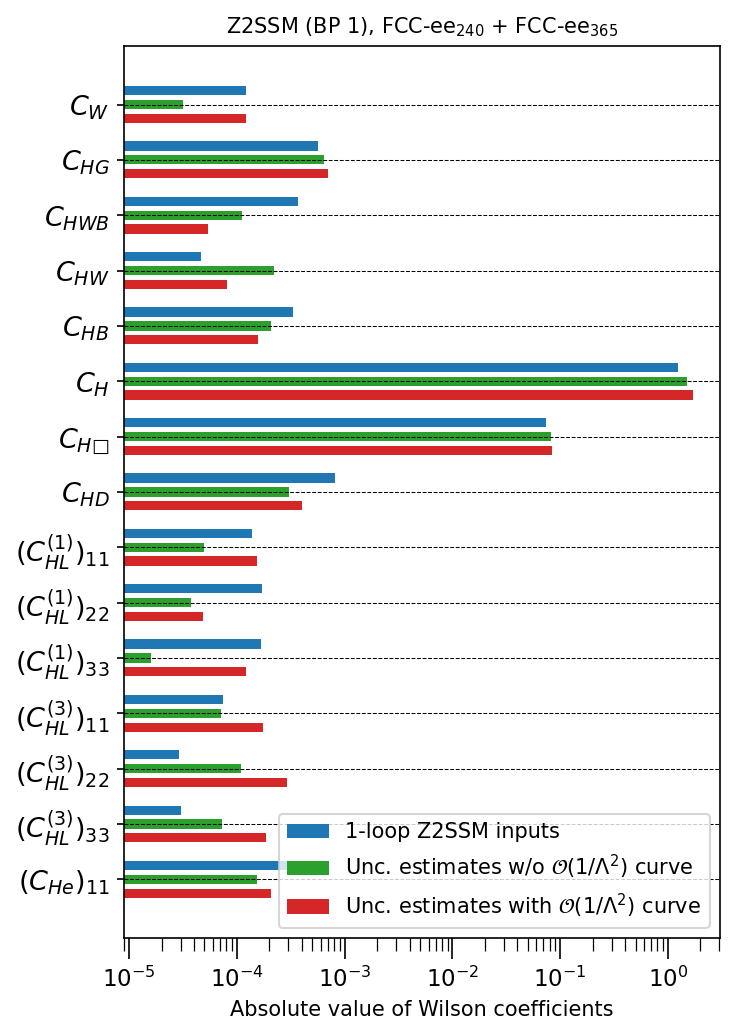

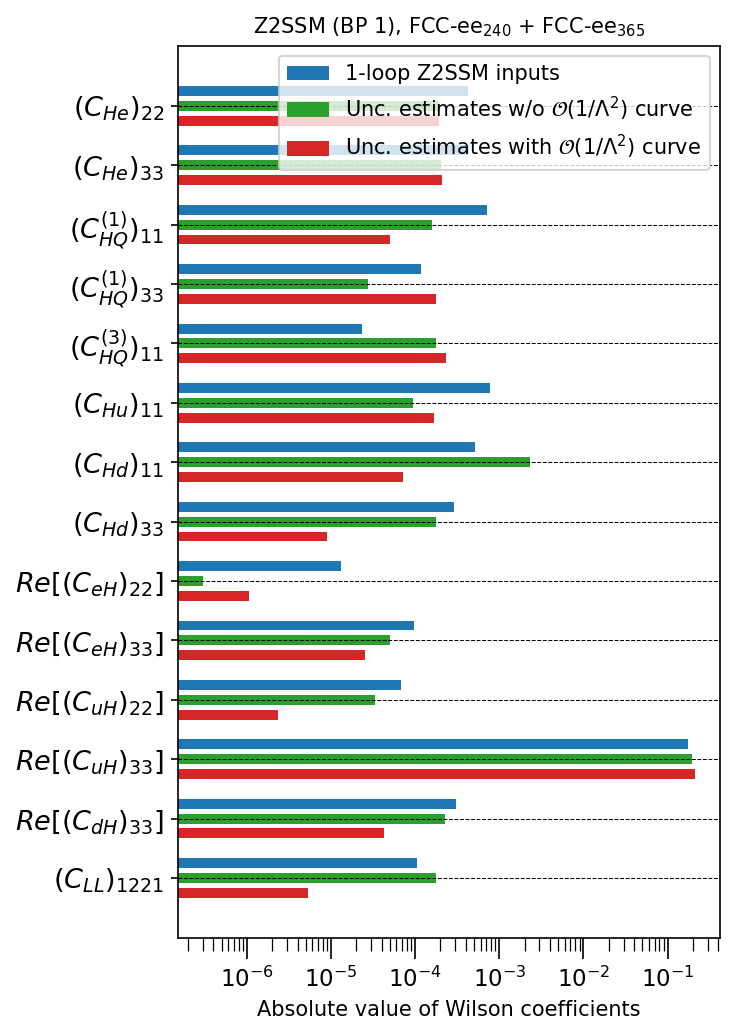

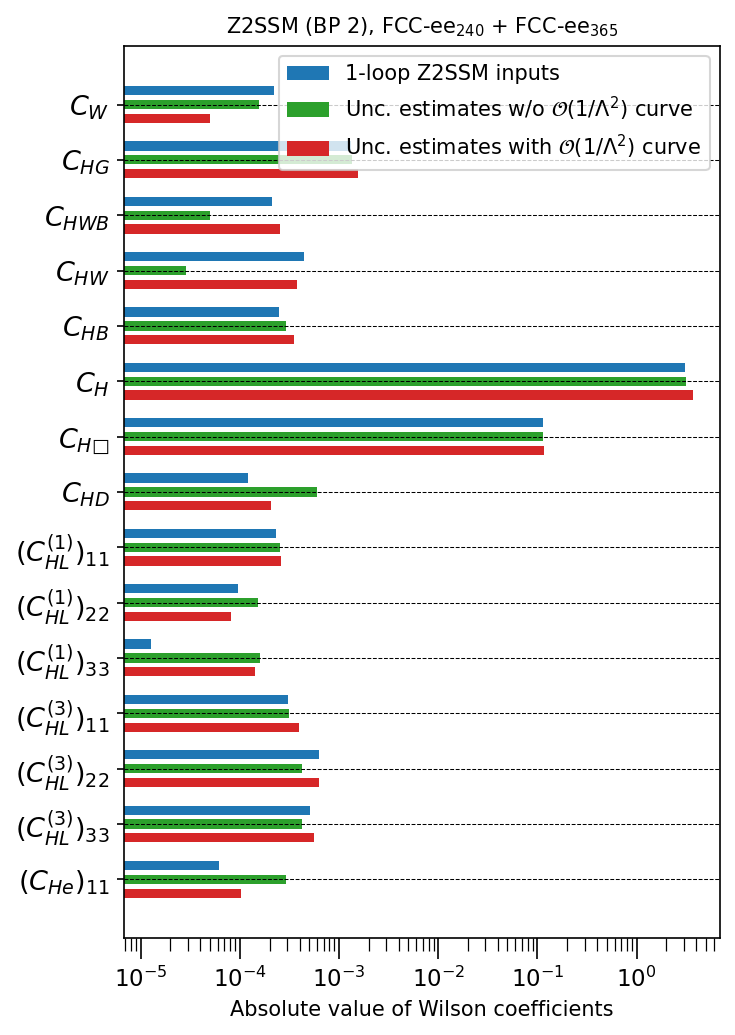

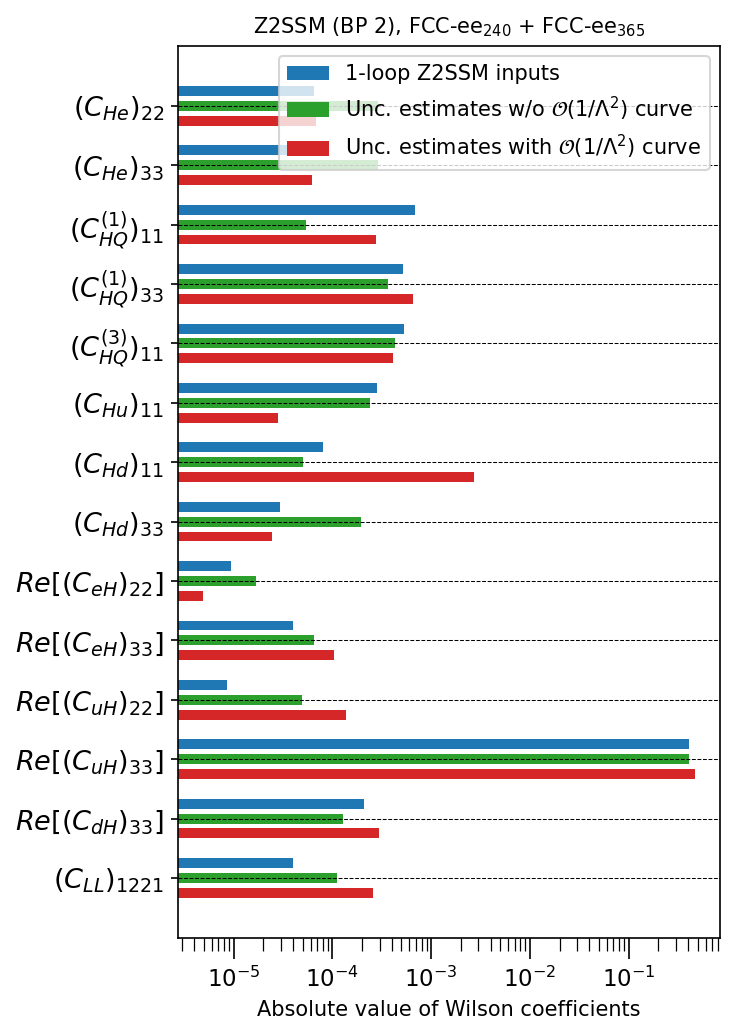

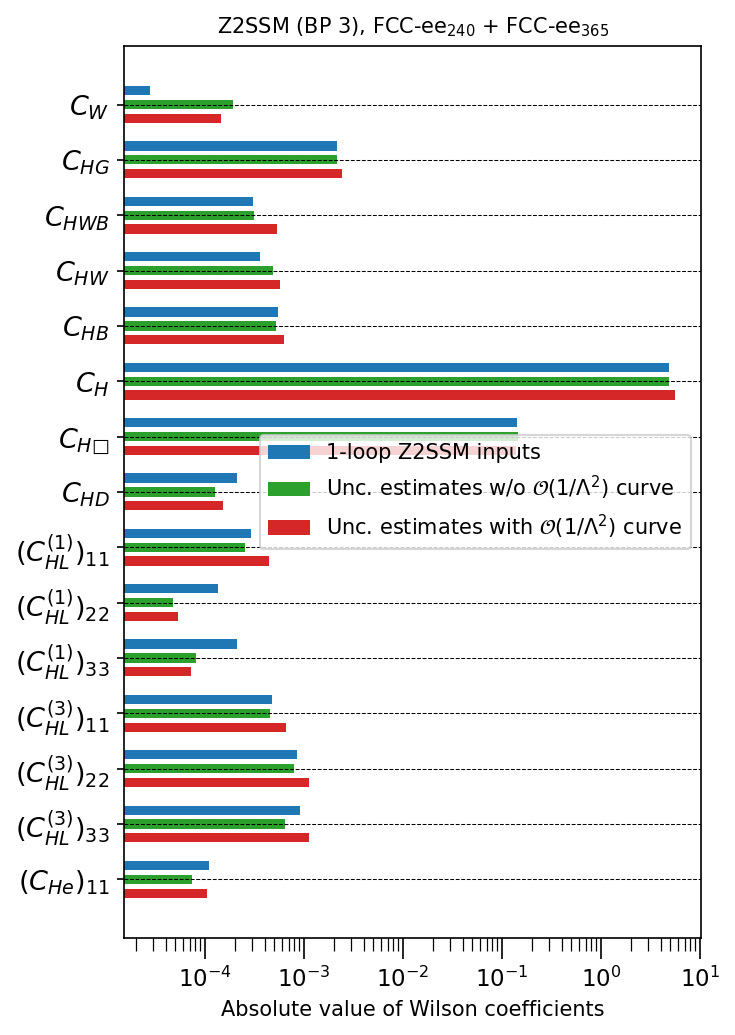

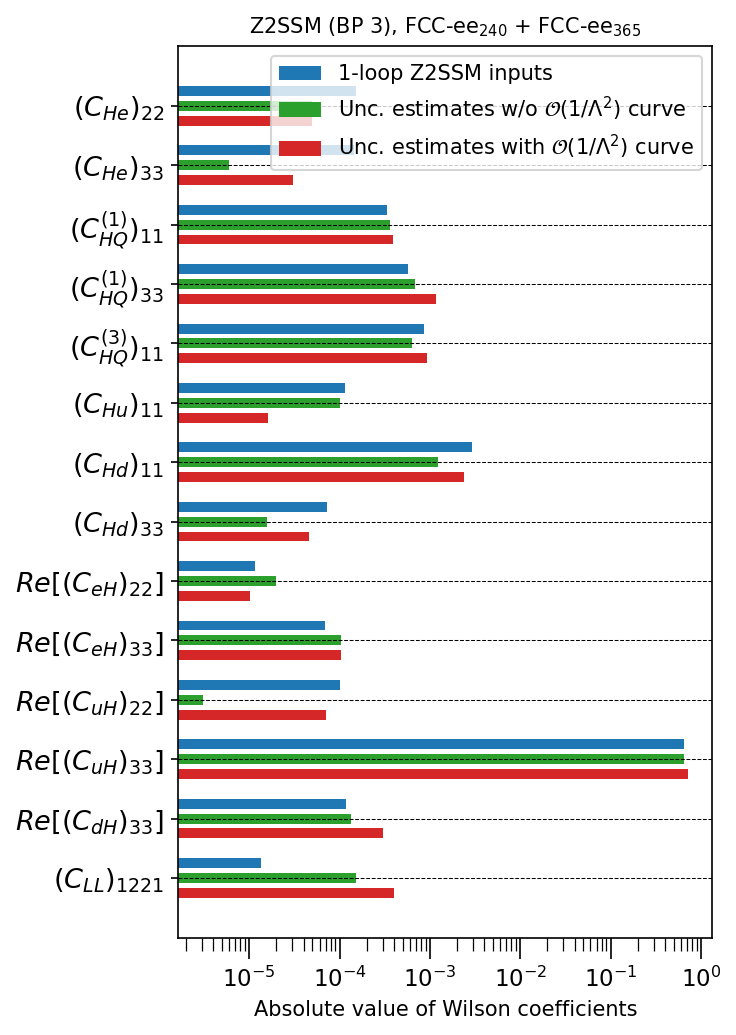

In [47]:
pullplots.generate_bar_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles_bps,
    model=model,
    colors=colors_specs,
    show_plots=True,
    nvar_per_plot=15,
    figsize=(5, 7),
    legend_loc="best",
    log_scale=True,
    # x_range_min=1e-3,
    # x_range_max=1e1,
)

## Generate pull plots for observables


Finding configuration files for the observables

Setting configuration files for scenario: Z2SSM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Full fit flag: one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long
Files considered:
- ObservablesEW.conf
- ObservablesEW_Current_SM_noLFU.conf
- ObservablesEW_FCCee_Zpole_SM_kappa_scaled.conf
- ObservablesEW_FCCee_WW_SM_kappa_scaled.conf
- ObservablesEW_HLLHC_kappa_scaled.conf
- ObservablesHiggs_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesHiggs_FCCee_240_SM_kappa_scaled_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesHiggs_HLLHC_SM_kappa_scaled_one_loop_inputs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesVV.conf
- aTGC_observables_Current.conf
- aTGC_observables_HLLHC_Full.conf
- ObservablesVV_OO_FCCee_161.conf
- Obs

/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),


137
[  0  50 100 137]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),


137
[  0  50 100 137]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),


137
[  0  50 100 137]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:530: RuntimeWarning: invalid value encountered in divide
  # -y,
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:531: RuntimeWarning: invalid value encountered in divide
  xerr=(results_errors[param_breaks[k]:param_breaks[k+1]],),


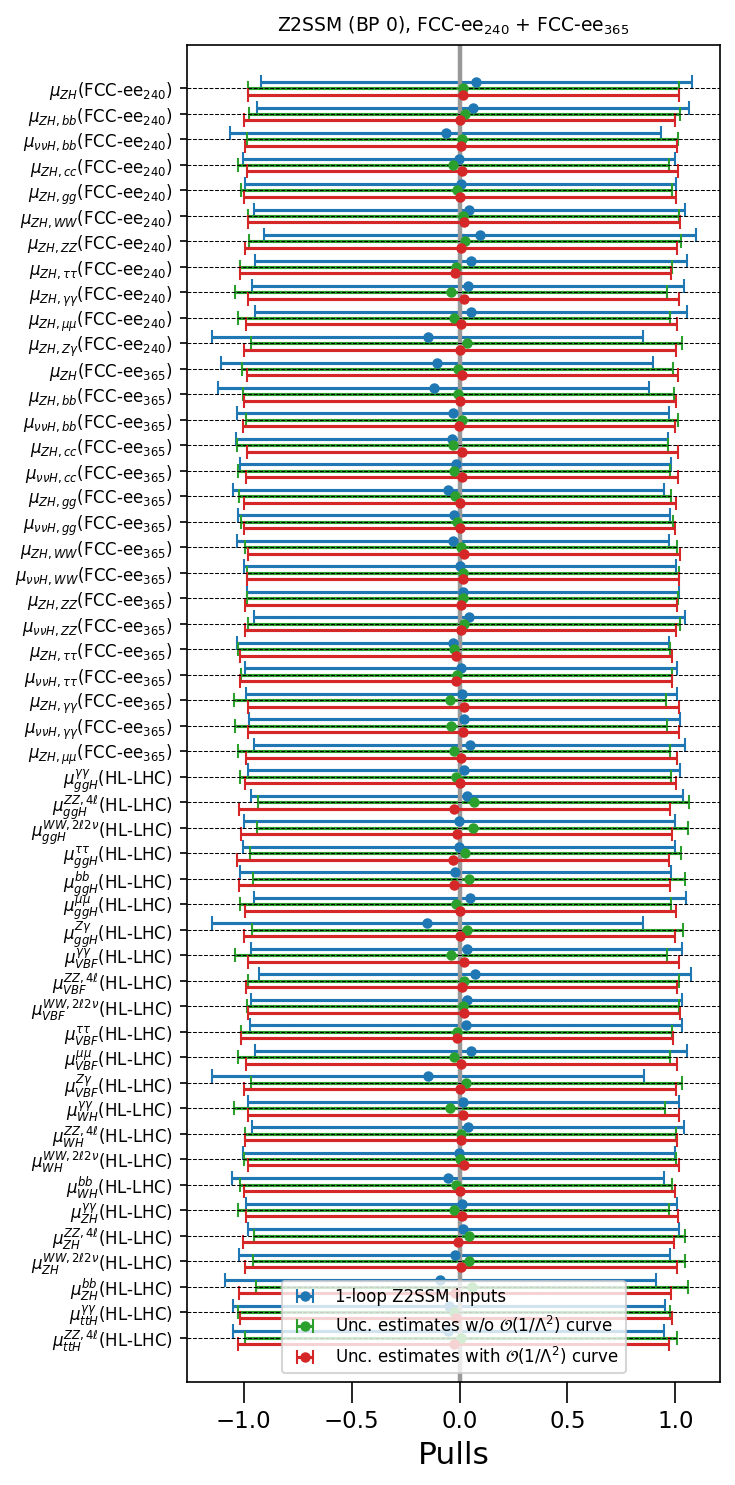

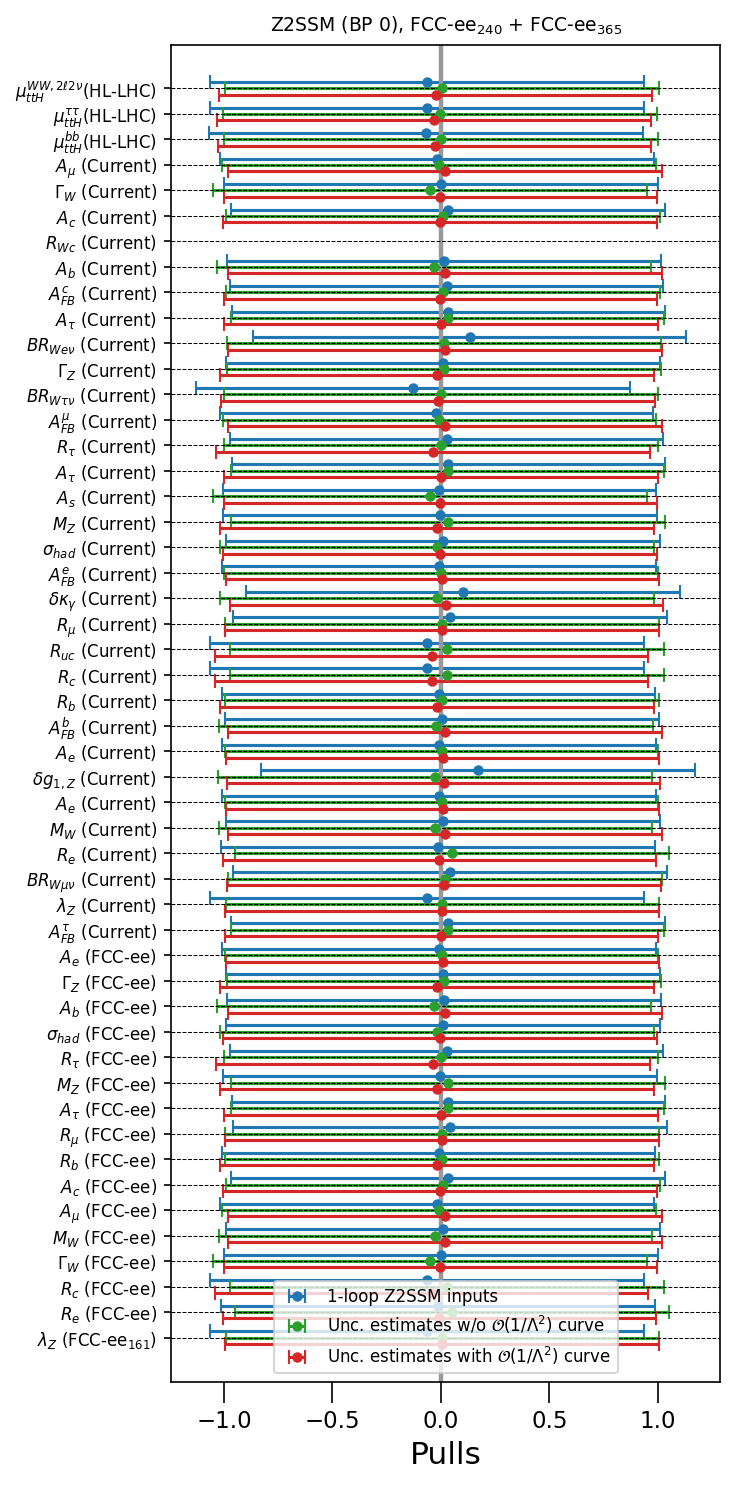

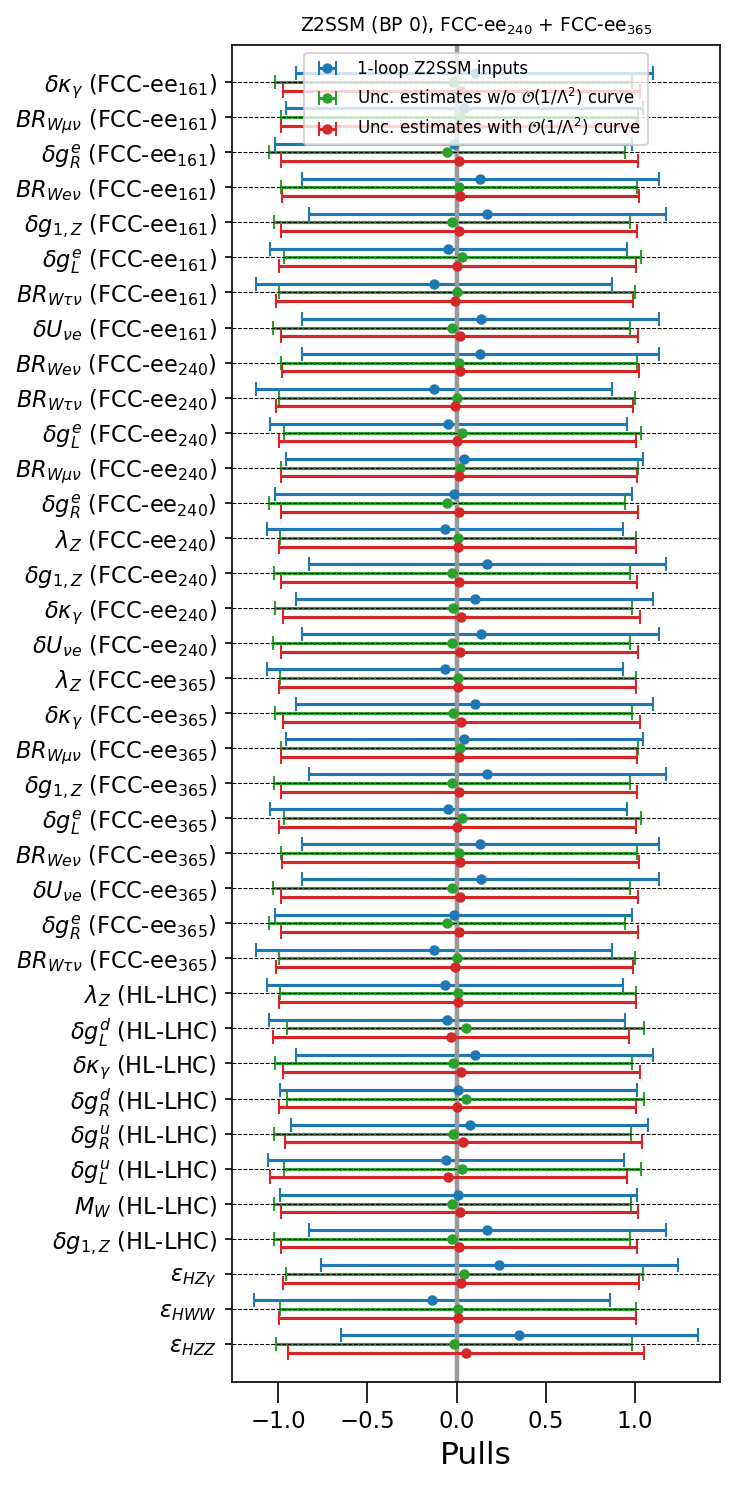

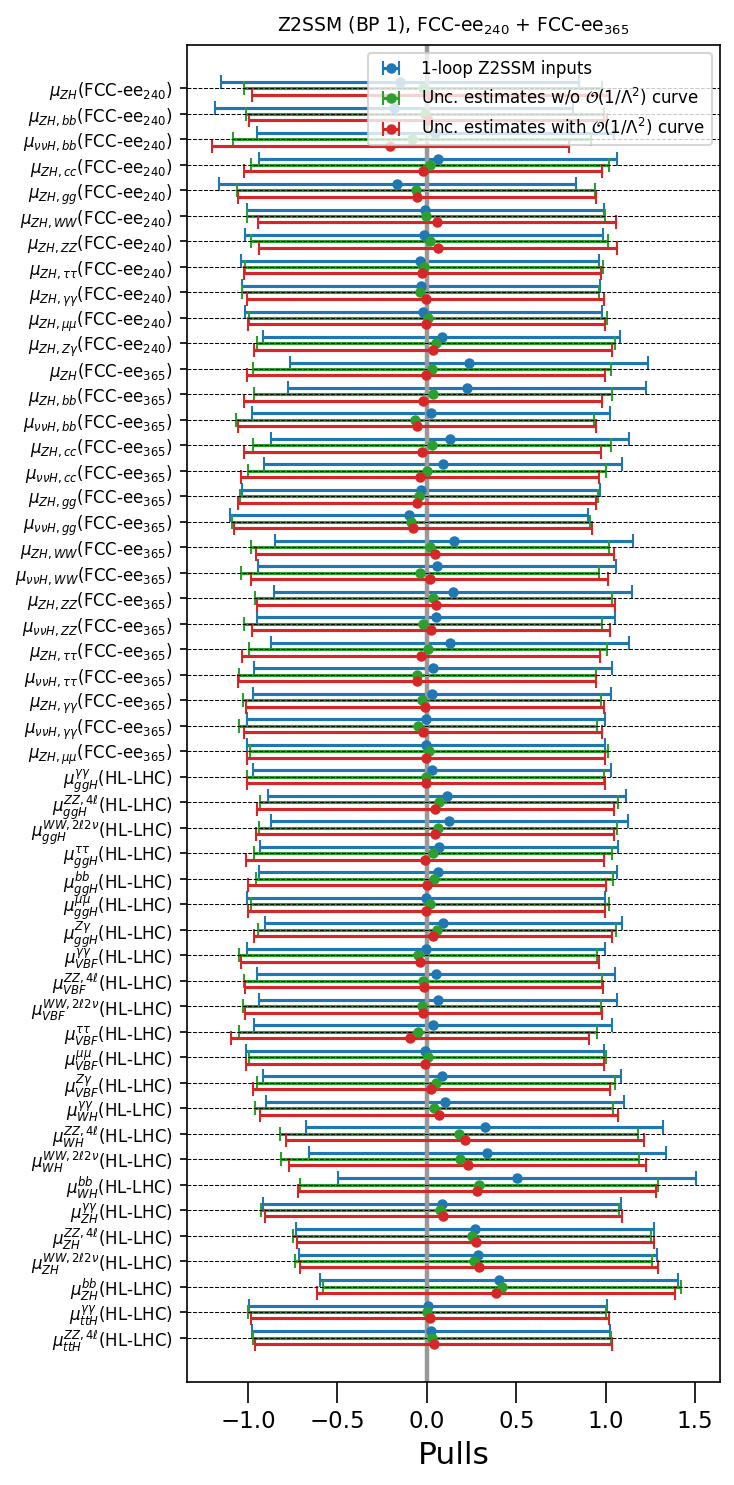

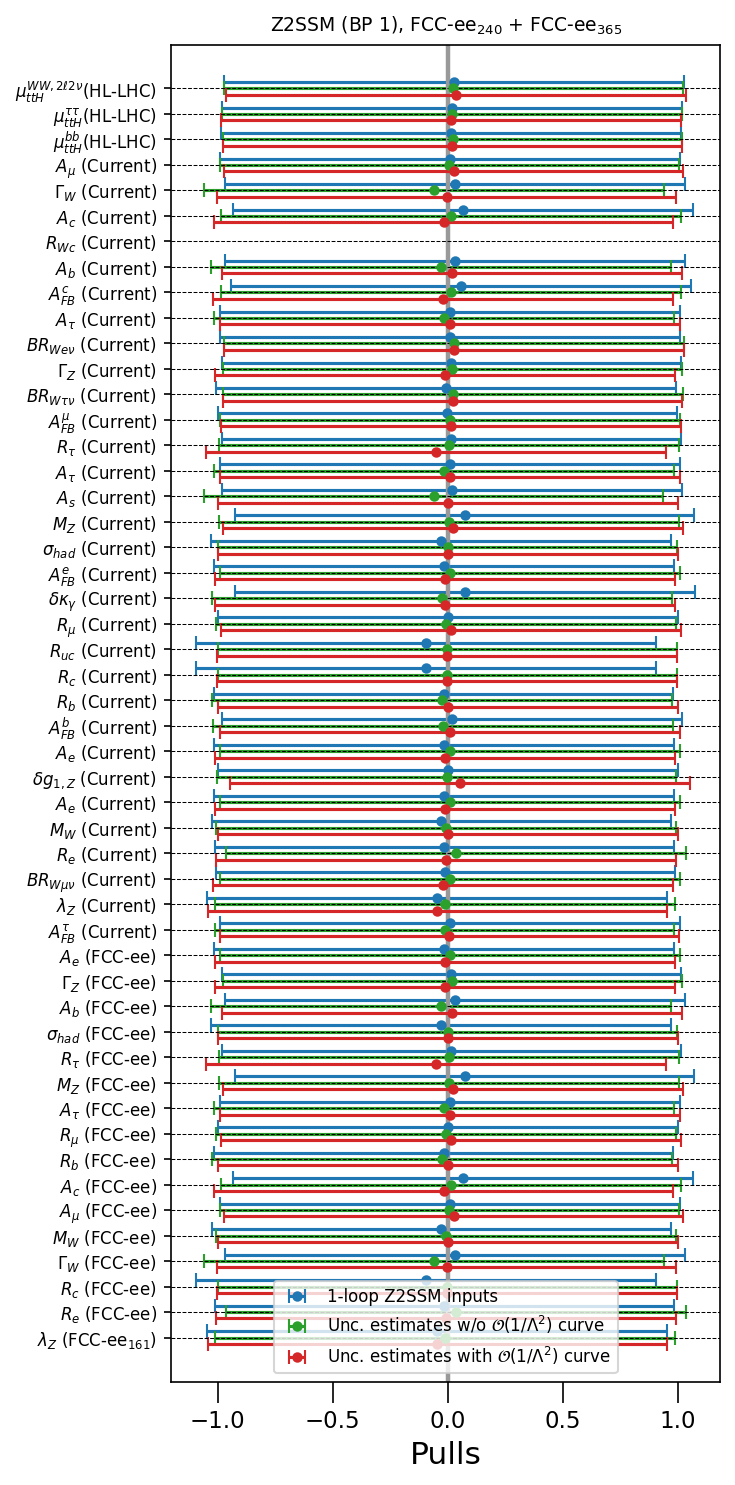

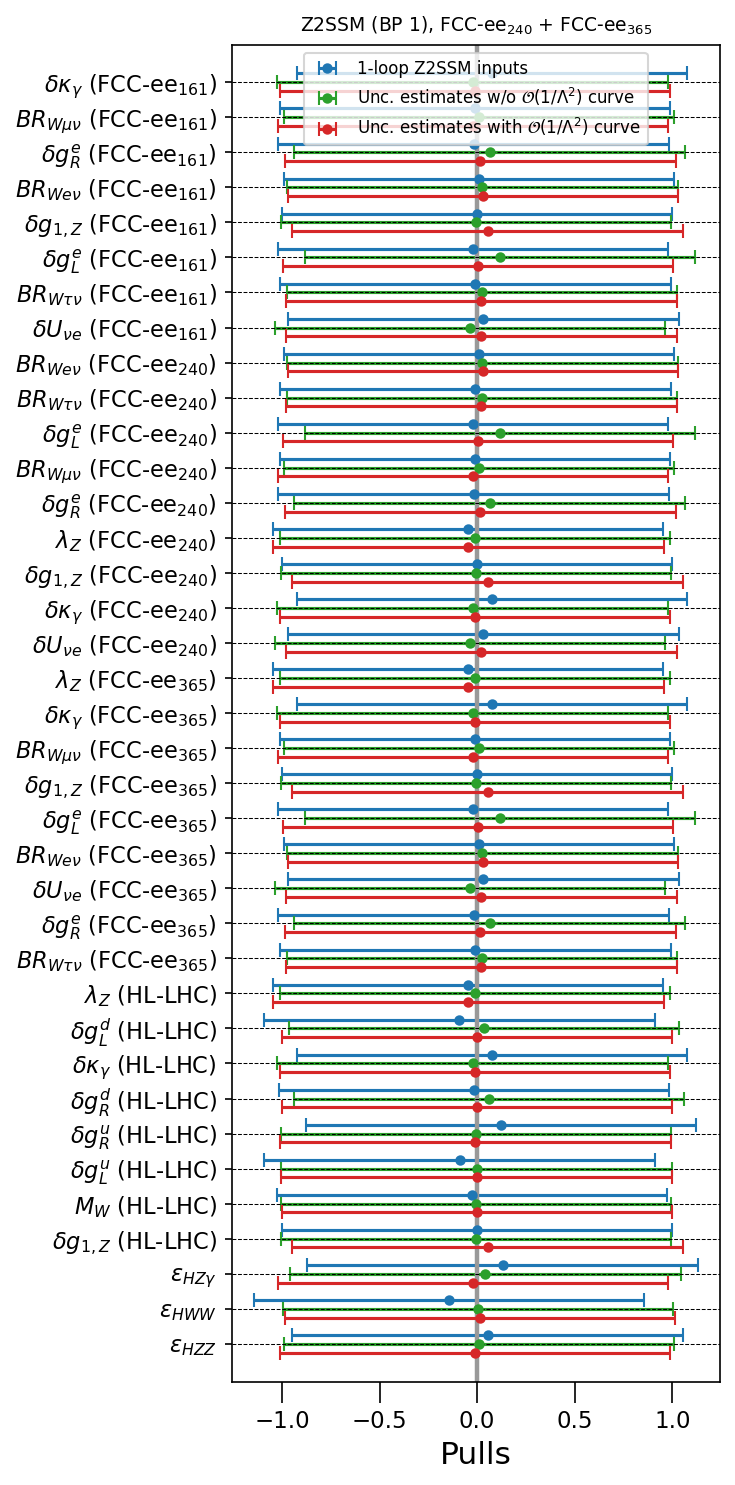

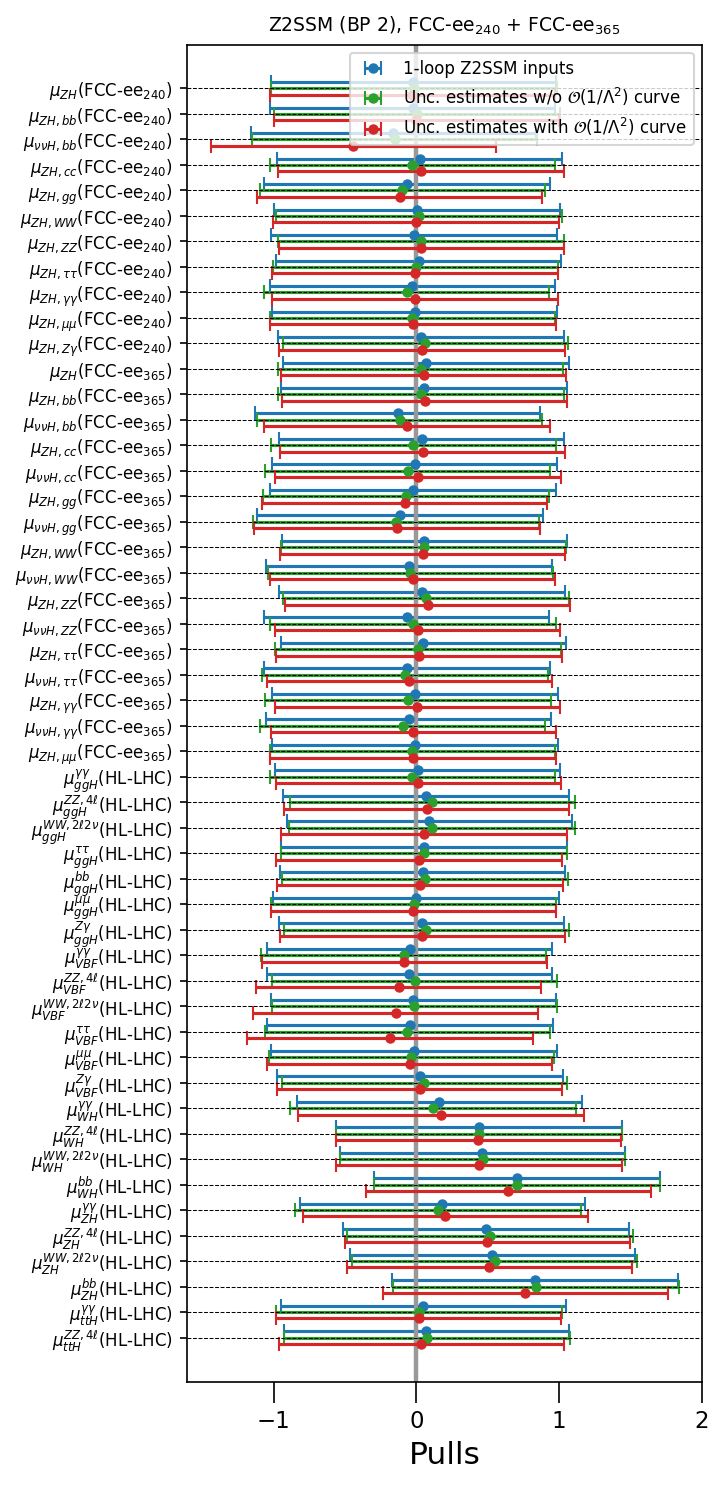

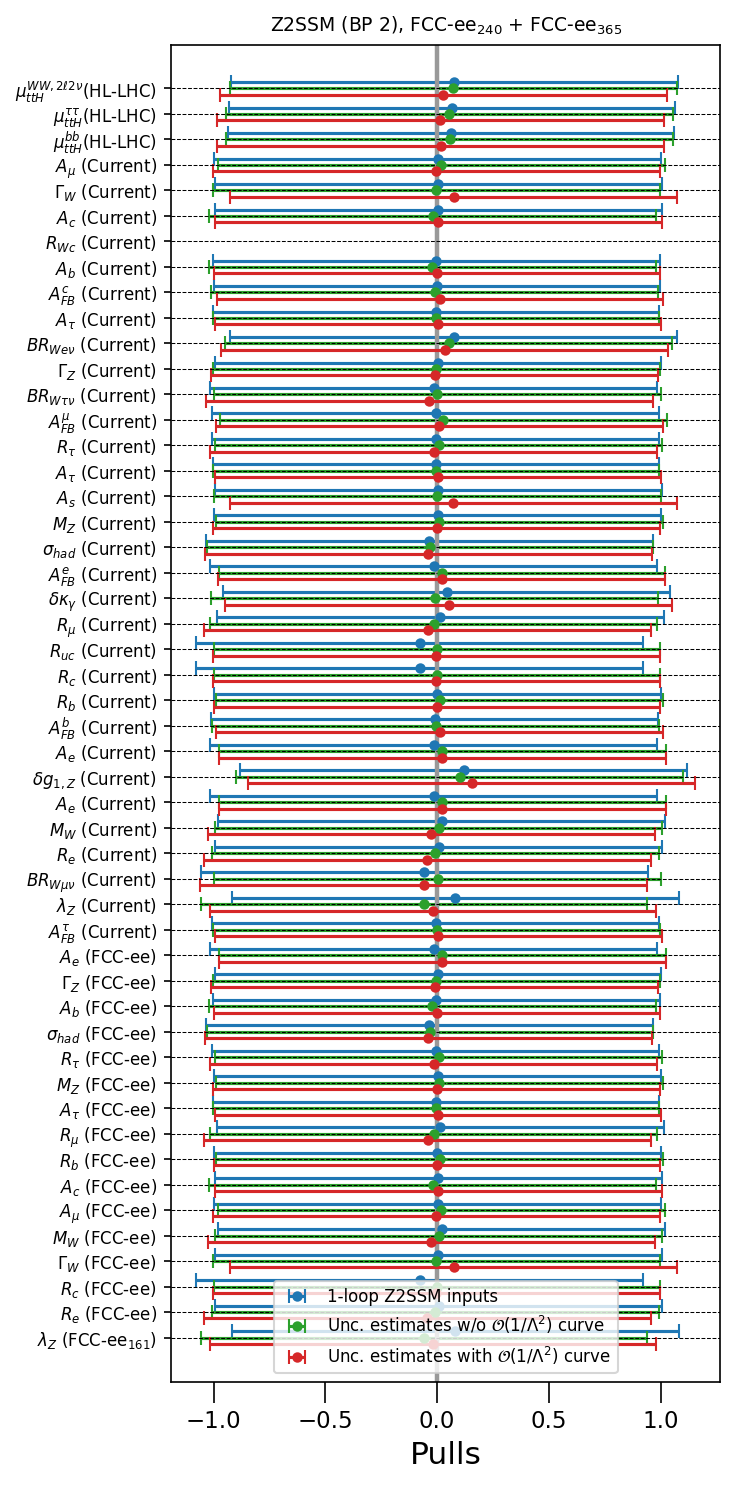

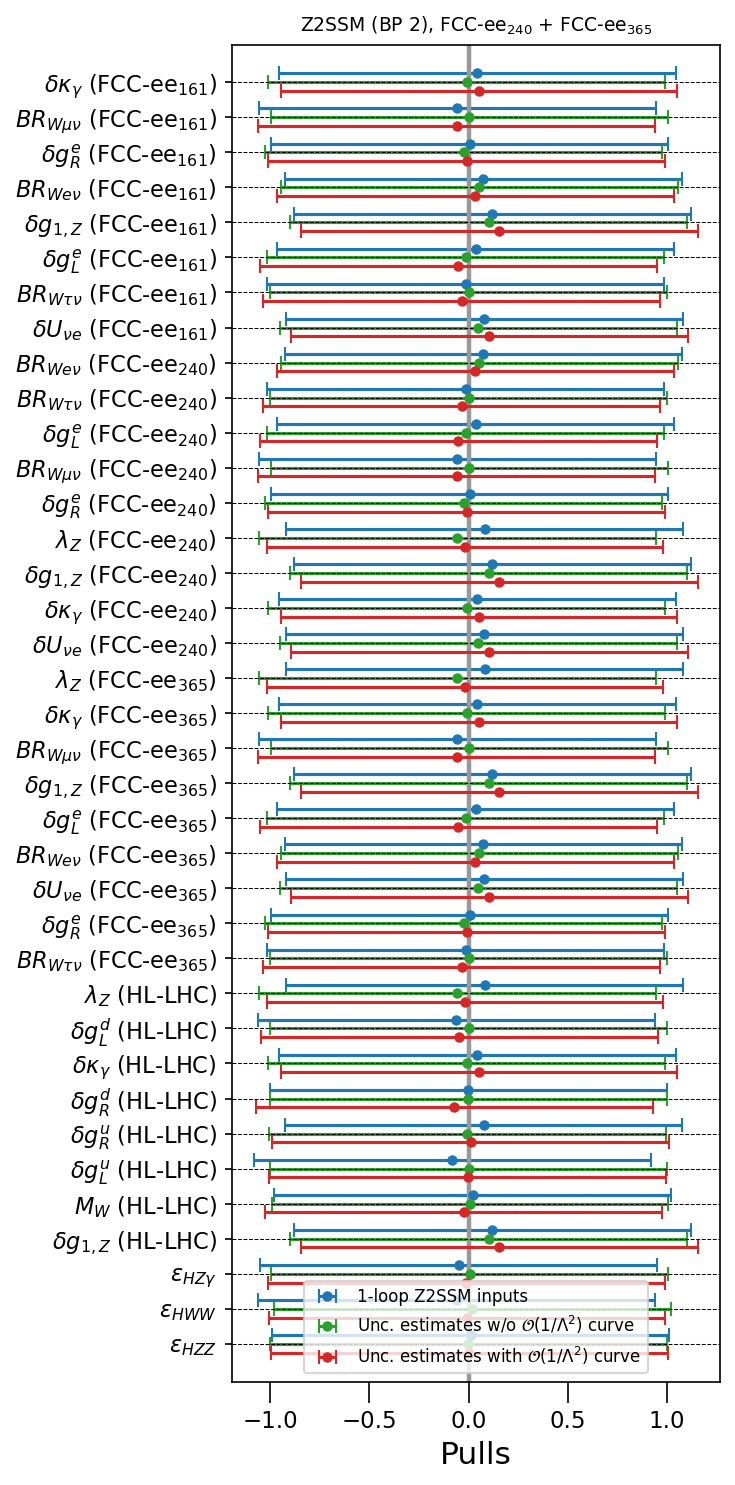

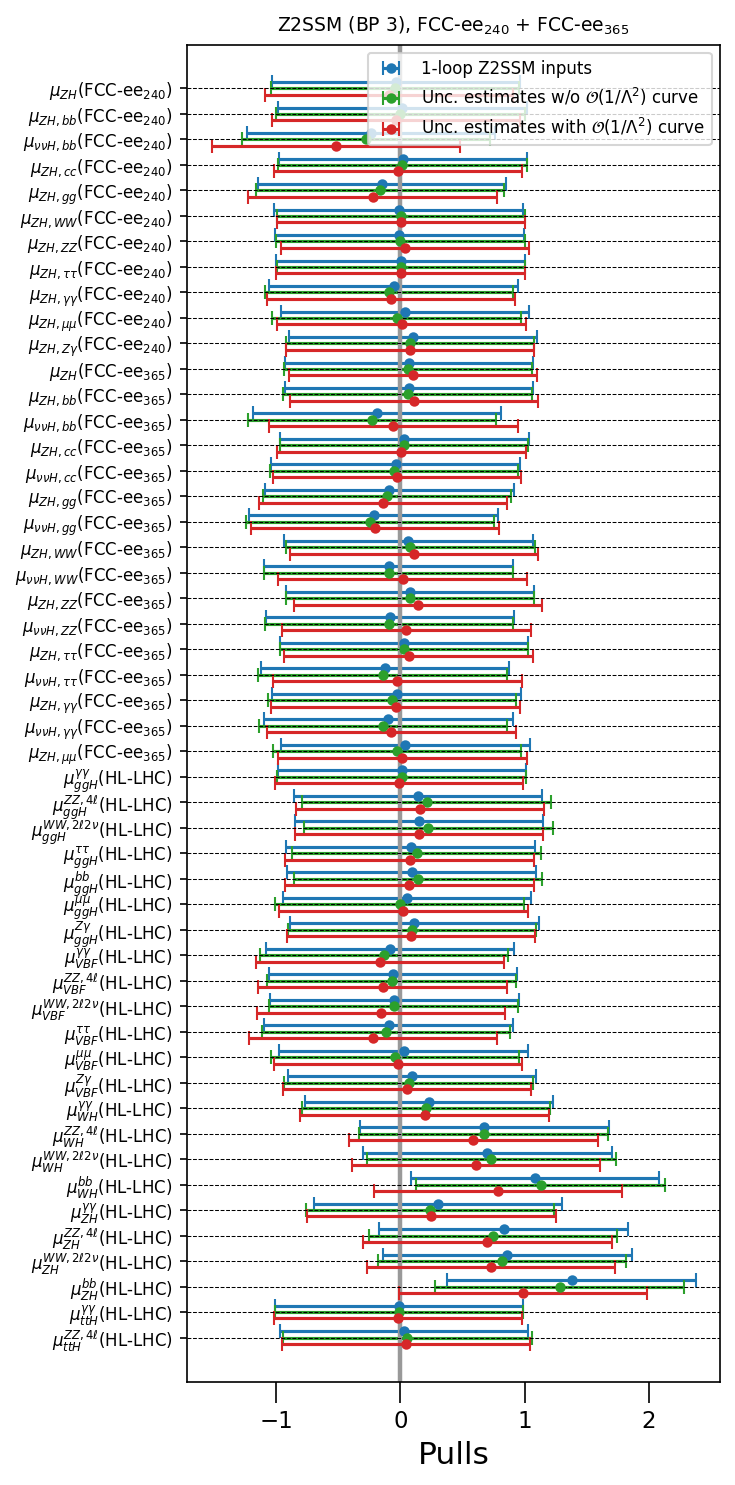

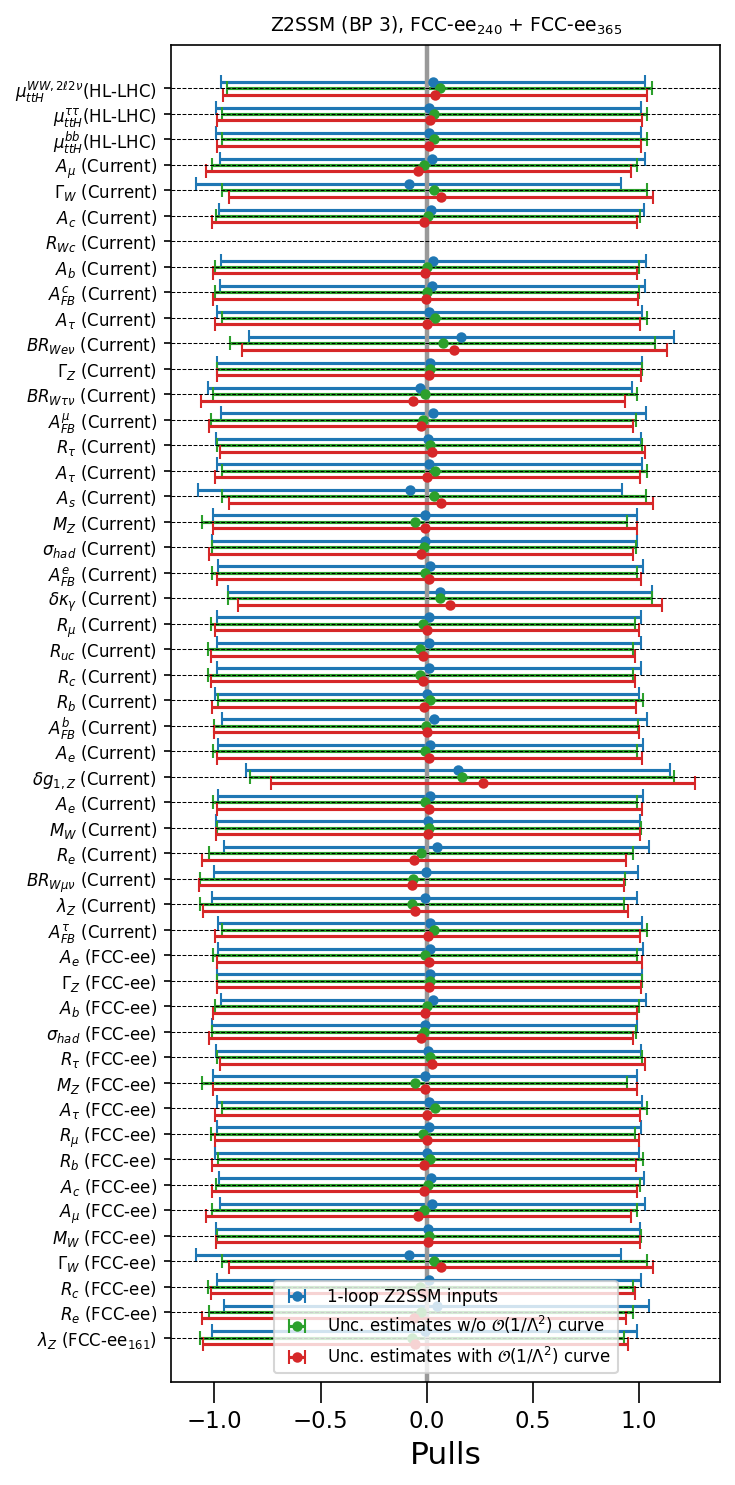

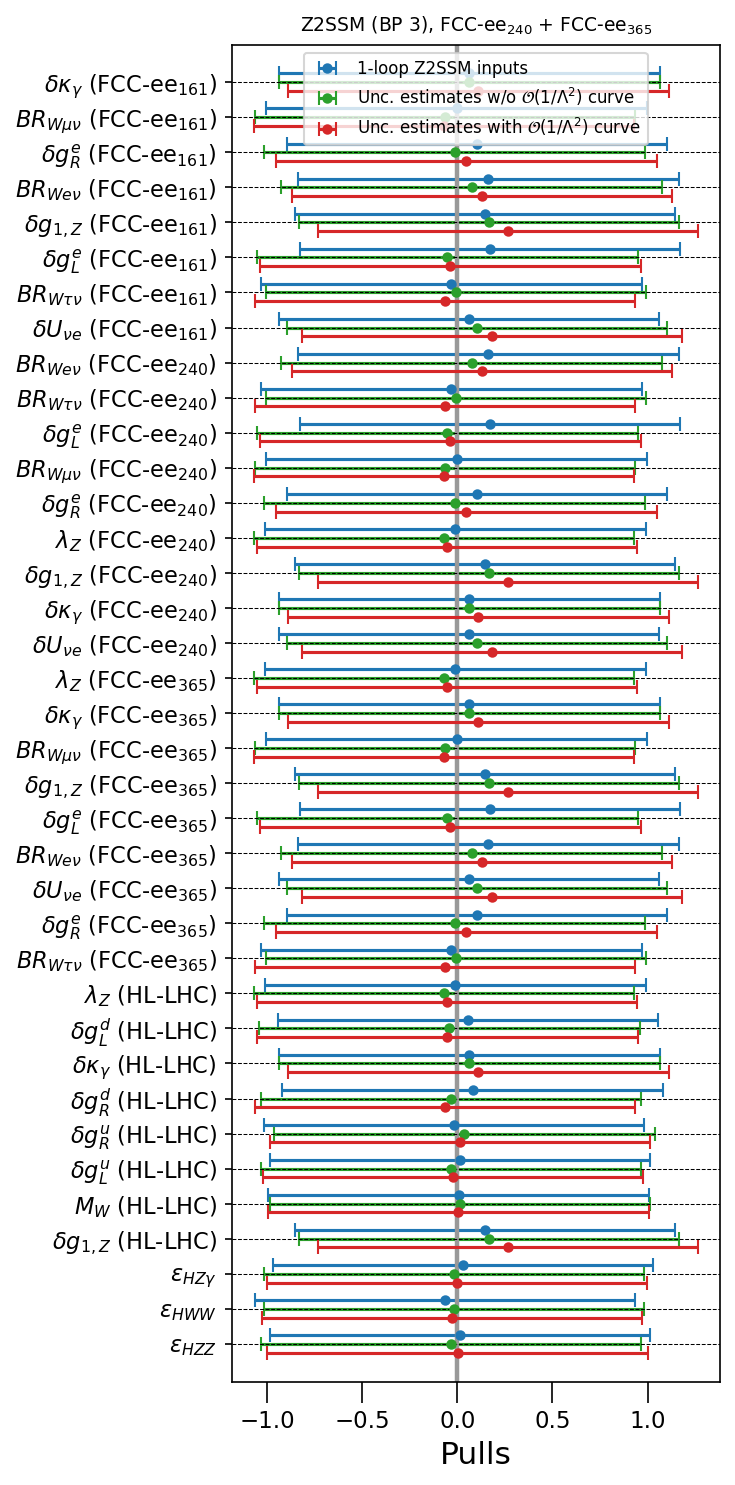

In [48]:
pullplots.generate_pull_plots_obs(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles_bps,
    model=model,
    colors=colors_specs,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 10),
)

In [49]:
raise NotImplementedError("Stop here when running the whole script")

NotImplementedError: Stop here when running the whole script

# One-loop Z2SSM $\leftrightarrow$ SMEFT Matching

In [ ]:
import pickle
vev = 246.
Mh = 125.

BP_input_dir = "/cephfs/user/mrebuzzi/phd/HiggsTools/future_projections/scan_output/Z2SSM_scan_output"
BP_dicts_filename = f"{BP_input_dir}/Benchmark_Points_outliers_dicts.pkl"

with open(BP_dicts_filename, 'rb') as f:
    BPs = pickle.load(f)
    bp_kappas = BPs["kappas"]
    bp_EWPOs = BPs["EWPOs"]
    bp_model_pars = BPs["model_pars"]
    bp_indices = BPs["indices"]

print("BP kappas:", bp_kappas)
print("BP EWPOs:", bp_EWPOs)
print("BP model parameters:", bp_model_pars)
print("BP indices:", bp_indices)

mS = np.array([bp["mS"] for bp in bp_model_pars]); print("\nmS:", mS)
muS = np.array([bp["muS"] for bp in bp_model_pars]); print("\nmuS:", muS)
lamS = np.array([bp["lamS"] for bp in bp_model_pars]); print("lamS:", lamS)
lamSH = np.array([bp["lamSH"] for bp in bp_model_pars]); print("lamSH:", lamSH)
bp_lambdas = np.array([bp["lam"] for bp in bp_kappas]); print("BP lambdas:", bp_lambdas)
bp_lambdas_1L = np.array([bp["lam1L"] for bp in bp_kappas]); print("BP lambdas (1L):", bp_lambdas_1L)

Z2SSM = EFT_matching.Z2SSM(muS=muS, lamS=lamS, lamSH=lamSH)
lamNP=1000 #GeV
matched_WCs = Z2SSM.get_coefficients(lamNP=lamNP)
print("\nMatched Wilson coefficients at lamNP =", lamNP, "GeV:\n", matched_WCs)
matched_kappa_lambdas = Z2SSM.get_kappa_lambda_SMEFT_match(lamNP=lamNP)
print("Matched SMEFT kappa_lambda at lamNP =", lamNP, "GeV:\n", matched_kappa_lambdas)
print("Model kappa_lambda predictions: ", bp_lambdas)


# Sort arrays
# sort_indices = [3, 5, 7, 9, 11]
# sort_indices = [0, 1, 2, 4, 6, 8, 10, 12, 13, ]
sort_indices = np.arange(14)

sort_indices = np.argsort(bp_lambdas)
bp_lambdas = bp_lambdas[sort_indices]
bp_lambdas_1L = bp_lambdas_1L[sort_indices]
matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]
mS = mS[sort_indices]
muS = muS[sort_indices]
lamS = lamS[sort_indices]
lamSH = lamSH[sort_indices]
CH    = matched_WCs["CH"]    [sort_indices]
CHbox = matched_WCs["CHbox"] [sort_indices]

BP kappas: [{'lam': 1.0643594459030925, 'kappaSingleHiggs': 0.997795157109014, 'lam1L': 1.0163047292403735, 'uu': 0.997795157109014, 'dd': 0.997795157109014, 'ss': 0.997795157109014, 'cc': 0.997795157109014, 'bb': 0.997795157109014, 'tt': 0.997795157109014, 'ee': 0.997795157109014, 'mumu': 0.997795157109014, 'tautau': 0.997795157109014, 'ZZ': 0.997795157109014, 'WW': 0.997795157109014, 'gamgam': 0.997795157109014, 'Zgam': 0.997795157109014, 'gg': 0.997795157109014, 'ZZ_0': 0.9980563471636651, 'ZZ_0_with_WFR': 0.9979539099793131, 'ZZ_0_no_BSM': 1.0002630443516598, 'ZZ_0_with_WFR_no_BSM': 1.0001608331788296, 'ZZ_240': 0.9983849781927755, 'ZZ_240_with_WFR': 0.9982825747303763, 'ZZ_240_no_BSM': 1.0005909506201627, 'ZZ_240_with_WFR_no_BSM': 1.000488772946644, 'ZZ_240_use_HEPfit_C1_values': 0.9983408359865786, 'ZZ_240_with_WFR_HEPfit_C1_values': 0.9982384279958877, 'ZZ_365': 0.9980039274452023, 'ZZ_365_with_WFR': 0.9979014848798298, 'ZZ_365_no_BSM': 1.0002107402832767, 'ZZ_365_with_WFR_no_BS

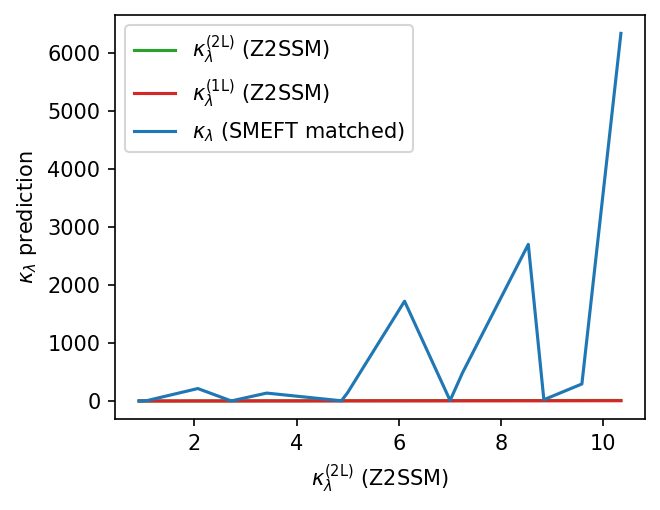

In [ ]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, bp_lambdas, color='tab:green', label=r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, bp_lambdas_1L, color='tab:red', label=r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (Z2SSM)')
ax.plot(bp_lambdas, matched_kappa_lambdas, color='tab:blue', label=r'$\kappa_{\lambda}$ (SMEFT matched)')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'$\kappa_{\lambda}$ prediction')
ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/kappa_lambda_matching_comparison.pdf")

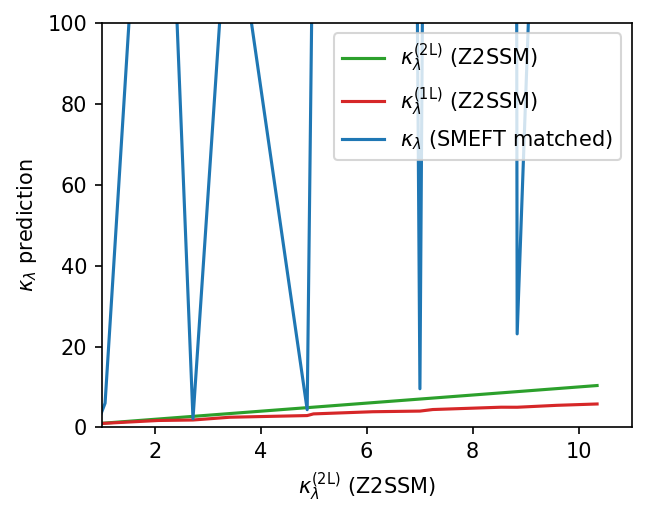

In [ ]:
ax.set_xlim(1,11)
ax.set_ylim(0,100)
fig.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_zoom.pdf")
fig

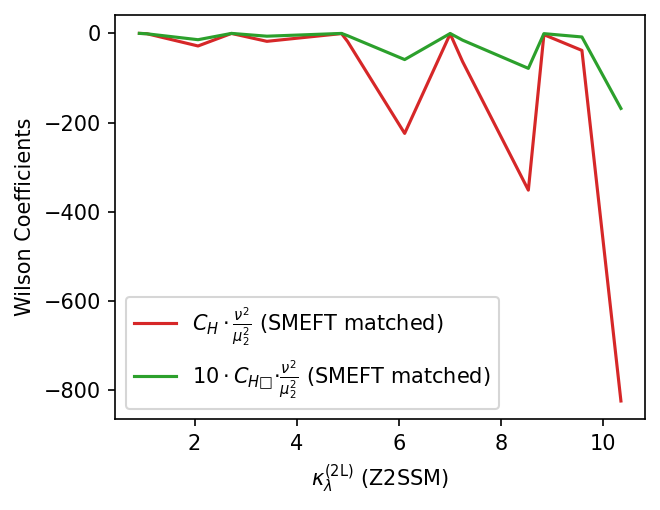

In [ ]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, CH*vev**2, color='tab:red', label=r'$C_{H}\cdot \frac{\nu^2}{\mu_{2}^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 10*CHbox*vev**2, color='tab:green', label='$10\cdot C_{H\u25A1}$'+r'$\cdot \frac{\nu^2}{\mu_{2}^{2}}$ (SMEFT matched)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Wilson Coefficients')
ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/WCs_matching_comparison.pdf")

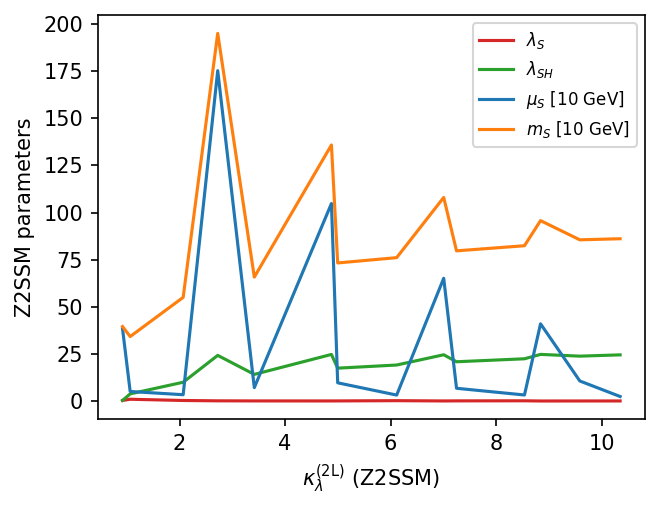

In [ ]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, lamS, color='tab:red', label=r'$\lambda_{S}$')
ax.plot(bp_lambdas, lamSH, color='tab:green', label=r'$\lambda_{SH}$')
ax.plot(bp_lambdas, muS/10., color='tab:blue', label=r'$\mu_{S}$ [10 GeV]')
ax.plot(bp_lambdas, mS/10., color='tab:orange', label=r'$m_{S}$ [10 GeV]')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (Z2SSM)')
ax.set_ylabel(r'Z2SSM parameters')
ax.legend(fontsize=8)
plt.tight_layout()

plt.savefig(f"{plot_dir}/Z2SSM_parameters_matching_comparison.pdf")